In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abhishek1812j/tesla-stock-news-dataset-20202022/tesla_news_2020_2022.csv


# 1.Import Libraries

## 1.1 Environment and Path Configuration

This notebook supports both **Kaggle** and **local repository** execution.  
Path resolution priority:
1. Local repository files (`data/...`)
2. Kaggle input/working paths (fallback)

This avoids hard-coded single-environment failures and improves reproducibility.

In [ ]:
from pathlib import Path
import os

# Detect environment
IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or Path('/kaggle').exists()

# Locate repository root when running locally
CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent, Path('/workspace/tesla-stock-prediction-fyp')]
REPO_ROOT = None
for candidate in CANDIDATE_ROOTS:
    if (candidate / 'notebooks').exists() and (candidate / 'data').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    REPO_ROOT = Path.cwd()

DATA_DIR = REPO_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
SAMPLE_DIR = DATA_DIR / 'sample'
LOG_DIR = REPO_ROOT / 'logs'
RESULTS_DIR = REPO_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Main file candidates: local first, Kaggle fallback
PATHS = {
    'sample_news': [
        SAMPLE_DIR / 'tesla_news_2020_2022_sample.csv',
        Path('/kaggle/input/datasets/abhishek1812j/tesla-stock-news-dataset-20202022/tesla_news_2020_2022.csv')
    ],
    'raw_alpha_news': [
        RAW_DIR / 'alphavantage_news_2023_2024_raw.csv',
        Path('/kaggle/working/alphavantage_news_2023_2024_raw.csv')
    ],
    'processed_stock': [
        PROCESSED_DIR / 'tsla_processed_with_indicators.csv',
        Path('/kaggle/working/tsla_processed_with_indicators.csv')
    ],
    'daily_sentiment': [
        PROCESSED_DIR / 'tesla_daily_sentiment_updated.csv',
        Path('/kaggle/working/tesla_daily_sentiment_updated.csv')
    ],
    'fused_dataset': [
        PROCESSED_DIR / 'tsla_fused_dataset.csv',
        Path('/kaggle/working/tsla_fused_dataset.csv')
    ]
}

def first_existing(candidates):
    for c in candidates:
        if Path(c).exists():
            return Path(c)
    return Path(candidates[0])

RESOLVED_PATHS = {k: first_existing(v) for k, v in PATHS.items()}

print(f'IS_KAGGLE = {IS_KAGGLE}')
print(f'REPO_ROOT = {REPO_ROOT}')
for k,v in RESOLVED_PATHS.items():
    print(f'{k}: {v}')

In [ ]:
expected_dirs = [REPO_ROOT / 'notebooks', RAW_DIR, PROCESSED_DIR, SAMPLE_DIR, LOG_DIR, RESULTS_DIR]
print('Directory checks:')
for d in expected_dirs:
    print(f' - {d}:', 'OK' if d.exists() else 'MISSING')

print('\nRequired file checks (current resolution):')
for k, path_obj in RESOLVED_PATHS.items():
    print(f' - {k}: {path_obj} ->', 'FOUND' if Path(path_obj).exists() else 'NOT FOUND')

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2.Stock Data Collection and Preprocessing

## 2.1 Download Tesla Stock Data

In [3]:
# Download Tesla stock data
df = yf.download("TSLA", start="2020-01-01", end="2024-12-31")

# Show first 5 rows
df.head()

/tmp/ipykernel_57/2393075220.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("TSLA", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [4]:
# Download additional market benchmark data
def download_close_series(ticker, close_name):
    temp = yf.download(ticker, start="2020-01-01", end="2024-12-31", progress=False)
    temp = temp.reset_index()

    # Handle possible MultiIndex columns from yfinance
    if isinstance(temp.columns, pd.MultiIndex):
        temp.columns = [col[0] for col in temp.columns]

    temp = temp[['Date', 'Close']].copy()
    temp = temp.rename(columns={'Close': close_name})
    temp['Date'] = pd.to_datetime(temp['Date'])
    return temp

qqq_df = download_close_series('QQQ', 'QQQ_Close')
spy_df = download_close_series('SPY', 'SPY_Close')
vix_df = download_close_series('^VIX', 'VIX_Close')

market_df = qqq_df.merge(spy_df, on='Date', how='outer').merge(vix_df, on='Date', how='outer')

print(market_df.head())
print(market_df.shape)

/tmp/ipykernel_57/2354059960.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp = yf.download(ticker, start="2020-01-01", end="2024-12-31", progress=False)
/tmp/ipykernel_57/2354059960.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp = yf.download(ticker, start="2020-01-01", end="2024-12-31", progress=False)
/tmp/ipykernel_57/2354059960.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp = yf.download(ticker, start="2020-01-01", end="2024-12-31", progress=False)


        Date   QQQ_Close   SPY_Close  VIX_Close
0 2020-01-02  208.317596  296.888153      12.47
1 2020-01-03  206.409409  294.640076      14.02
2 2020-01-06  207.739304  295.764221      13.85
3 2020-01-07  207.710403  294.932617      13.79
4 2020-01-08  209.271622  296.504425      13.45
(1257, 4)


In [5]:
print(df.shape)

(1257, 5)


## 2.2 Clean and Prepare Stock Data

In [6]:
# Reset index so Date becomes a normal column
df = df.reset_index()

# Flatten column names if they are multi-level
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] if col[1] == 'TSLA' or col[1] == '' else '_'.join(col).strip() for col in df.columns]

# Standardize Date format before merge
df['Date'] = pd.to_datetime(df['Date'])
market_df['Date'] = pd.to_datetime(market_df['Date'])

# Merge Tesla data with market benchmark data
df = df.merge(market_df, on='Date', how='left')

# Show columns
print(df.columns)

# Preview data
print(df[['Date', 'Close', 'QQQ_Close', 'SPY_Close', 'VIX_Close']].head())

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'QQQ_Close',
       'SPY_Close', 'VIX_Close'],
      dtype='object')
        Date      Close   QQQ_Close   SPY_Close  VIX_Close
0 2020-01-02  28.684000  208.317596  296.888153      12.47
1 2020-01-03  29.534000  206.409409  294.640076      14.02
2 2020-01-06  30.102667  207.739304  295.764221      13.85
3 2020-01-07  31.270666  207.710403  294.932617      13.79
4 2020-01-08  32.809334  209.271622  296.504425      13.45


In [7]:
# Save the raw trading calendar BEFORE target filtering and technical-indicator cleaning
raw_trading_dates = (
    pd.to_datetime(df['Date'], errors='coerce')
      .dt.normalize()
      .dropna()
      .drop_duplicates()
      .sort_values()
)

raw_trading_index = pd.Index(raw_trading_dates)

print("Raw trading calendar start:", raw_trading_index.min())
print("Raw trading calendar end:", raw_trading_index.max())
print("Number of trading dates:", len(raw_trading_index))

Raw trading calendar start: 2020-01-02 00:00:00
Raw trading calendar end: 2024-12-30 00:00:00
Number of trading dates: 1257


In [8]:
print(df['Date'].min())
print(df['Date'].max())

2020-01-02 00:00:00
2024-12-30 00:00:00


In [9]:
print(df.isnull().sum())

Date         0
Close        0
High         0
Low          0
Open         0
Volume       0
QQQ_Close    0
SPY_Close    0
VIX_Close    0
dtype: int64


## 2.3 Create Target Variable

In [10]:
import numpy as np
import pandas as pd

# Fixed baseline threshold for label construction
# Later threshold tuning must be done ONLY on the training set
TARGET_THRESHOLD = 0.007

# Ensure stock data is sorted by date
df = df.sort_values('Date').reset_index(drop=True).copy()

# Next-day close and next-day return
df['Next_Day_Close'] = df['Close'].shift(-1)
df['Next_Day_Return'] = (df['Next_Day_Close'] / df['Close']) - 1

# Label construction
# 1 = clear upward movement
# 0 = clear downward movement
# NaN = neutral / noisy movement
df['Target'] = np.select(
    [
        df['Next_Day_Return'] > TARGET_THRESHOLD,
        df['Next_Day_Return'] < -TARGET_THRESHOLD
    ],
    [1, 0],
    default=np.nan
)

print("Fixed target threshold:", TARGET_THRESHOLD)
print(df[['Date', 'Close', 'Next_Day_Close', 'Next_Day_Return', 'Target']].head(10))

print("\nTarget counts before removing neutral samples:")
print(df['Target'].value_counts(dropna=False).sort_index())

Fixed target threshold: 0.007
        Date      Close  Next_Day_Close  Next_Day_Return  Target
0 2020-01-02  28.684000       29.534000         0.029633     1.0
1 2020-01-03  29.534000       30.102667         0.019255     1.0
2 2020-01-06  30.102667       31.270666         0.038801     1.0
3 2020-01-07  31.270666       32.809334         0.049205     1.0
4 2020-01-08  32.809334       32.089333        -0.021945     0.0
5 2020-01-09  32.089333       31.876667        -0.006627     NaN
6 2020-01-10  31.876667       34.990665         0.097689     1.0
7 2020-01-13  34.990665       35.861332         0.024883     1.0
8 2020-01-14  35.861332       34.566666        -0.036102     0.0
9 2020-01-15  34.566666       34.232666        -0.009662     0.0

Target counts before removing neutral samples:
Target
0.0    483
1.0    532
NaN    242
Name: count, dtype: int64


In [11]:
label_summary = (
    df['Target']
    .value_counts(dropna=False)
    .rename_axis('Target')
    .reset_index(name='Count')
)

label_summary['Ratio'] = (label_summary['Count'] / len(df)).round(4)

print("Label distribution before filtering neutral samples:")
print(label_summary)

valid_label_count = df['Target'].notna().sum()
neutral_count = df['Target'].isna().sum()

print("\nValid labeled samples:", valid_label_count)
print("Neutral / noisy samples removed later:", neutral_count)

Label distribution before filtering neutral samples:
   Target  Count   Ratio
0     1.0    532  0.4232
1     0.0    483  0.3842
2     NaN    242  0.1925

Valid labeled samples: 1015
Neutral / noisy samples removed later: 242


### Prediction Task Definition

This study predicts the direction of Tesla's next trading-day return.  
For each trading day t, the model uses information available by the end of day t to predict whether the stock price will move up or down on trading day t+1.

Target definition:
- 1 = next-day return is greater than +0.7%
- 0 = next-day return is less than -0.7%
- values between -0.7% and +0.7% are treated as neutral/noisy and excluded from modeling

News alignment rule:
- news published on a trading day is assigned to that trading day
- news published after market close is assigned to the next trading day if timestamp is available
- weekend or holiday news is assigned to the next available trading day
- if only calendar date is available without intraday time, the stated date is used and this is treated as a data limitation

## 2.4 Generate Technical Indicators

In [12]:
# =========================
# Original technical indicators (keep all)
# =========================

# Simple moving averages
df['MA7'] = df['Close'].rolling(window=7, min_periods=7).mean()
df['MA14'] = df['Close'].rolling(window=14, min_periods=14).mean()

# Exponential moving averages
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()

# MACD family
df['MACD'] = df['EMA12'] - df['EMA26']
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_hist'] = df['MACD'] - df['MACD_signal']

# RSI
delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14, min_periods=14).mean()
avg_loss = loss.rolling(window=14, min_periods=14).mean()

rs = avg_gain / avg_loss.replace(0, np.nan)
df['RSI'] = 100 - (100 / (1 + rs))
df.loc[(avg_loss == 0) & (avg_gain > 0), 'RSI'] = 100
df.loc[(avg_gain == 0) & (avg_loss > 0), 'RSI'] = 0
df.loc[(avg_gain == 0) & (avg_loss == 0), 'RSI'] = 50

# Returns and momentum
df['Return_1'] = df['Close'].pct_change(1)
df['Return_3'] = df['Close'].pct_change(3)
df['Return_5'] = df['Close'].pct_change(5)

# Volume and volatility
df['Volume_Change'] = df['Volume'].pct_change()
df['Volatility_5'] = df['Close'].pct_change().rolling(window=5, min_periods=5).std()
df['Volatility_10'] = df['Close'].pct_change().rolling(window=10, min_periods=10).std()

# Intraday structure
df['Price_Range'] = (df['High'] - df['Low']) / df['Close']
df['Open_Close_Return'] = (df['Close'] - df['Open']) / df['Open']

# =========================
# New stronger technical indicators
# =========================

# Gap feature
df['Gap_Return'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)

# Relative moving-average features
df['MA7_Gap'] = (df['Close'] - df['MA7']) / df['MA7']
df['MA14_Gap'] = (df['Close'] - df['MA14']) / df['MA14']
df['EMA12_Gap'] = (df['Close'] - df['EMA12']) / df['EMA12']
df['EMA26_Gap'] = (df['Close'] - df['EMA26']) / df['EMA26']
df['MA_Cross'] = (df['MA7'] - df['MA14']) / df['MA14']
df['EMA_Cross'] = (df['EMA12'] - df['EMA26']) / df['EMA26']

# Medium-term momentum
df['Momentum_10'] = df['Close'].pct_change(10)
df['Momentum_20'] = df['Close'].pct_change(20)

# Volume strength
df['Volume_Ratio_5'] = df['Volume'] / df['Volume'].rolling(window=5, min_periods=5).mean()
df['Volume_Ratio_10'] = df['Volume'] / df['Volume'].rolling(window=10, min_periods=10).mean()

# OBV
price_direction = np.sign(df['Close'].diff()).fillna(0)
df['OBV'] = (price_direction * df['Volume']).cumsum()
df['OBV_Change_5'] = df['OBV'].pct_change(5)

# ATR
high_low = df['High'] - df['Low']
high_prev_close = (df['High'] - df['Close'].shift(1)).abs()
low_prev_close = (df['Low'] - df['Close'].shift(1)).abs()
true_range = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
df['ATR_14'] = true_range.rolling(window=14, min_periods=14).mean()
df['ATR_Ratio_14'] = df['ATR_14'] / df['Close']

# Bollinger Bands
bb_mid = df['Close'].rolling(window=20, min_periods=20).mean()
bb_std = df['Close'].rolling(window=20, min_periods=20).std()
bb_upper = bb_mid + 2 * bb_std
bb_lower = bb_mid - 2 * bb_std

df['Bollinger_Width_20'] = (bb_upper - bb_lower) / bb_mid
df['Bollinger_Position_20'] = (df['Close'] - bb_lower) / (bb_upper - bb_lower)

# Stochastic oscillator
lowest_low_14 = df['Low'].rolling(window=14, min_periods=14).min()
highest_high_14 = df['High'].rolling(window=14, min_periods=14).max()
df['Stoch_K_14'] = 100 * (df['Close'] - lowest_low_14) / (highest_high_14 - lowest_low_14)
df['Stoch_D_3'] = df['Stoch_K_14'].rolling(window=3, min_periods=3).mean()

# =========================
# New market environment features
# =========================

df['QQQ_Return_1'] = df['QQQ_Close'].pct_change(1)
df['QQQ_Return_5'] = df['QQQ_Close'].pct_change(5)
df['QQQ_Volatility_5'] = df['QQQ_Close'].pct_change().rolling(window=5, min_periods=5).std()

df['SPY_Return_1'] = df['SPY_Close'].pct_change(1)
df['SPY_Return_5'] = df['SPY_Close'].pct_change(5)

df['VIX_Return_1'] = df['VIX_Close'].pct_change(1)
df['VIX_Change_5'] = df['VIX_Close'].pct_change(5)
df['VIX_Relative_10'] = (df['VIX_Close'] / df['VIX_Close'].rolling(window=10, min_periods=10).mean()) - 1

# Relative strength vs market
df['TSLA_vs_QQQ_Return_1'] = df['Return_1'] - df['QQQ_Return_1']
df['TSLA_vs_SPY_Return_1'] = df['Return_1'] - df['SPY_Return_1']

# Clean infinite values
df = df.replace([np.inf, -np.inf], np.nan)

# Keep original technical indicators + newly added ones
technical_columns = [
    # original ones
    'MA7', 'MA14', 'EMA12', 'EMA26',
    'RSI', 'MACD', 'MACD_signal', 'MACD_hist',
    'Return_1', 'Return_3', 'Return_5',
    'Volume_Change', 'Volatility_5', 'Volatility_10',
    'Price_Range', 'Open_Close_Return',

    # new technical indicators
    'Gap_Return',
    'MA7_Gap', 'MA14_Gap', 'EMA12_Gap', 'EMA26_Gap',
    'MA_Cross', 'EMA_Cross',
    'Momentum_10', 'Momentum_20',
    'Volume_Ratio_5', 'Volume_Ratio_10',
    'OBV_Change_5',
    'ATR_Ratio_14',
    'Bollinger_Width_20', 'Bollinger_Position_20',
    'Stoch_K_14', 'Stoch_D_3',

    # market environment features
    'QQQ_Return_1', 'QQQ_Return_5', 'QQQ_Volatility_5',
    'SPY_Return_1', 'SPY_Return_5',
    'VIX_Return_1', 'VIX_Change_5', 'VIX_Relative_10',
    'TSLA_vs_QQQ_Return_1', 'TSLA_vs_SPY_Return_1'
]

print(df[technical_columns].isnull().sum())

MA7                       6
MA14                     13
EMA12                     0
EMA26                     0
RSI                      14
MACD                      0
MACD_signal               0
MACD_hist                 0
Return_1                  1
Return_3                  3
Return_5                  5
Volume_Change             1
Volatility_5              5
Volatility_10            10
Price_Range               0
Open_Close_Return         0
Gap_Return                1
MA7_Gap                   6
MA14_Gap                 13
EMA12_Gap                 0
EMA26_Gap                 0
MA_Cross                 13
EMA_Cross                 0
Momentum_10              10
Momentum_20              20
Volume_Ratio_5            4
Volume_Ratio_10           9
OBV_Change_5              6
ATR_Ratio_14             13
Bollinger_Width_20       19
Bollinger_Position_20    19
Stoch_K_14               13
Stoch_D_3                15
QQQ_Return_1              1
QQQ_Return_5              5
QQQ_Volatility_5    

## 2.5 Handle Missing Values

In [13]:
required_columns = [
    'Date', 'Open', 'High', 'Low', 'Close', 'Volume',
    'Next_Day_Return', 'Target'
] + technical_columns

before_rows = len(df)

# Keep only rows with complete features and clear target labels
df = df.dropna(subset=required_columns).copy()
df['Target'] = df['Target'].astype(int)
df = df.reset_index(drop=True)

after_rows = len(df)

print(f"Rows before cleaning: {before_rows}")
print(f"Rows after cleaning:  {after_rows}")
print(f"Rows removed:         {before_rows - after_rows}")
print(df[['Date', 'Close', 'Next_Day_Return', 'Target'] + technical_columns[:6]].head())
print(df['Target'].value_counts())

Rows before cleaning: 1257
Rows after cleaning:  998
Rows removed:         259
        Date      Close  Next_Day_Return  Target        MA7       MA14  \
0 2020-01-31  43.371334         0.198949       1  39.374381  37.411143   
1 2020-02-03  52.000000         0.137256       1  41.353428  38.626095   
2 2020-02-04  59.137333        -0.171758       0  44.422381  40.288667   
3 2020-02-05  48.980000         0.019409       1  46.105047  41.318190   
4 2020-02-07  49.871334         0.031026       1  49.430191  43.570762   

       EMA12      EMA26        RSI      MACD  
0  38.210763  35.279857  83.725839  2.930907  
1  40.332184  36.518386  87.704673  3.813799  
2  43.225284  38.193863  90.377940  5.031421  
3  44.110625  38.992836  69.123265  5.117789  
4  45.754527  40.548845  70.751007  5.205681  
Target
1    520
0    478
Name: count, dtype: int64


In [14]:
print(df.isnull().sum())

Date                     0
Close                    0
High                     0
Low                      0
Open                     0
Volume                   0
QQQ_Close                0
SPY_Close                0
VIX_Close                0
Next_Day_Close           0
Next_Day_Return          0
Target                   0
MA7                      0
MA14                     0
EMA12                    0
EMA26                    0
MACD                     0
MACD_signal              0
MACD_hist                0
RSI                      0
Return_1                 0
Return_3                 0
Return_5                 0
Volume_Change            0
Volatility_5             0
Volatility_10            0
Price_Range              0
Open_Close_Return        0
Gap_Return               0
MA7_Gap                  0
MA14_Gap                 0
EMA12_Gap                0
EMA26_Gap                0
MA_Cross                 0
EMA_Cross                0
Momentum_10              0
Momentum_20              0
V

In [15]:
df.head()

,Date,Close,High,Low,Open,Volume,QQQ_Close,SPY_Close,VIX_Close,Next_Day_Close,...,QQQ_Return_1,QQQ_Return_5,QQQ_Volatility_5,SPY_Return_1,SPY_Return_5,VIX_Return_1,VIX_Change_5,VIX_Relative_10,TSLA_vs_QQQ_Return_1,TSLA_vs_SPY_Return_1
0,2020-01-31,43.371334,43.533333,42.167999,42.666668,235789500,211.121964,294.018585,18.840000,52.000000,...,-0.015858,-0.016300,0.014819,-0.018158,-0.021413,0.216269,0.293956,0.250747,0.031089,0.033389
1,2020-02-03,52.000000,52.409332,44.901333,44.912666,705975000,214.311874,296.202759,17.969999,59.137333,...,0.015109,0.019624,0.012773,0.007429,0.001917,-0.046178,-0.014262,0.148243,0.183839,0.191520
2,2020-02-04,59.137333,64.599335,55.591999,58.863998,914082000,219.217255,300.717316,16.049999,48.980000,...,0.022889,0.027185,0.014745,0.015241,0.006638,-0.106845,-0.014128,0.005009,0.114367,0.122015
3,2020-02-05,48.980000,56.398666,46.940666,54.883999,726357000,219.939972,304.189972,15.150000,49.930668,...,0.003297,0.028898,0.014655,0.011548,0.019105,-0.056075,-0.075656,-0.064468,-0.175055,-0.183306
4,2020-02-07,49.871334,51.316666,48.666668,48.703335,255952500,220.884445,303.586823,15.470000,51.418667,...,-0.004301,0.046241,0.010485,-0.005330,0.032543,0.034091,-0.178875,-0.061457,0.003112,0.004142


## 2.6 Save Processed Dataset

In [16]:
# Save processed stock data
stock_out_path = PROCESSED_DIR / 'tsla_processed_with_indicators.csv'
stock_out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(stock_out_path, index=False)

print("File saved successfully.")

File saved successfully.


In [17]:
import os
if IS_KAGGLE and Path('/kaggle/working').exists():
    print('Kaggle working dir files:', os.listdir('/kaggle/working'))
else:
    output_dir = PROCESSED_DIR if PROCESSED_DIR.exists() else RESULTS_DIR
    print(f'Local output dir files ({output_dir}):', os.listdir(output_dir) if output_dir.exists() else 'DIR NOT FOUND')

['tsla_processed_with_indicators.csv', '.virtual_documents']


# 3. Exploratory Data Analysis (EDA)

## 3.1 Closing Price Trend

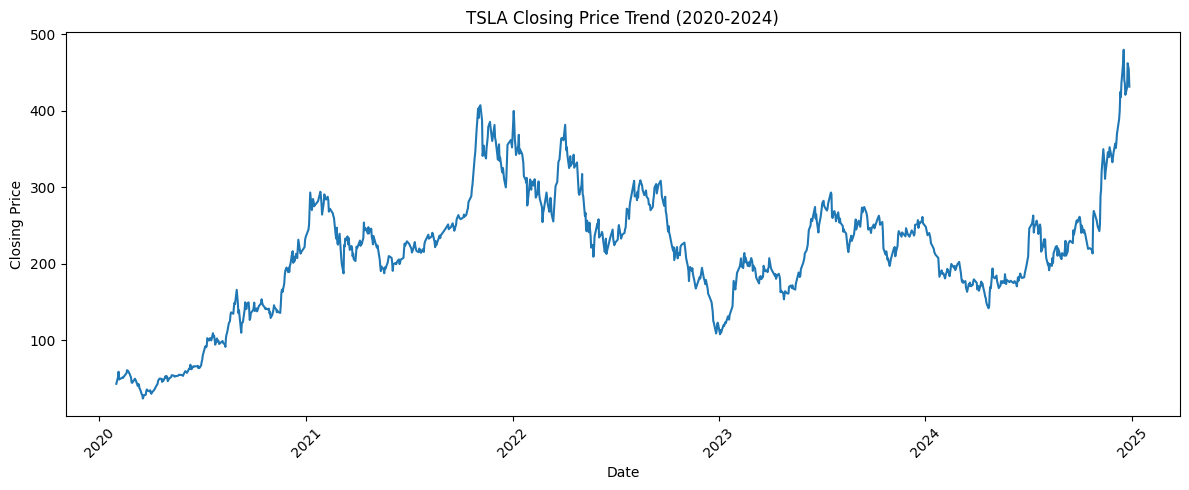

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'])
plt.title('TSLA Closing Price Trend (2020-2024)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation
The closing price trend shows that Tesla stock experienced substantial fluctuations during 2020–2024.  
From 2020 to 2021, the stock price increased rapidly, reflecting a strong upward trend.  
In 2022 and 2023, the stock price became more volatile, with several sharp rises and declines.  
By the end of 2024, Tesla's stock price rose sharply again, indicating renewed market momentum.  

This result suggests that Tesla stock is highly dynamic and volatile, which supports the need for predictive modeling using both historical price information and additional features.

## 3.2 Target Distribution

Target distribution:
Target
1    520
0    478
Name: count, dtype: int64


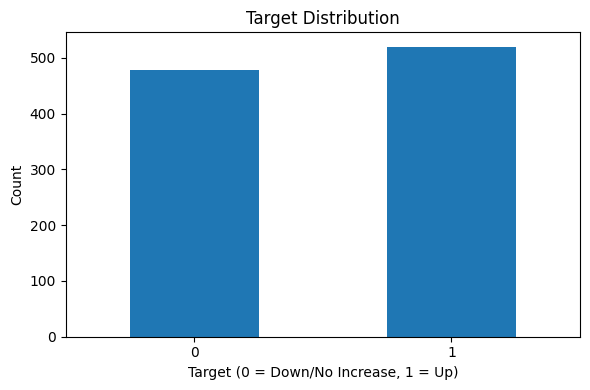

In [19]:
print("Target distribution:")
print(df['Target'].value_counts())

plt.figure(figsize=(6, 4))
df['Target'].value_counts().sort_index().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Target (0 = Down/No Increase, 1 = Up)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation
The target distribution is relatively balanced, with 650 instances labeled as 1 (price increase) and 579 instances labeled as 0 (price decrease or no increase).  
Although there are slightly more upward movements than downward movements, the difference is not extreme.  

This indicates that the dataset does not suffer from severe class imbalance, which is beneficial for building a binary classification model.  
Therefore, the target variable is suitable for next-day stock movement prediction.

## 3.3 Moving Average Trend

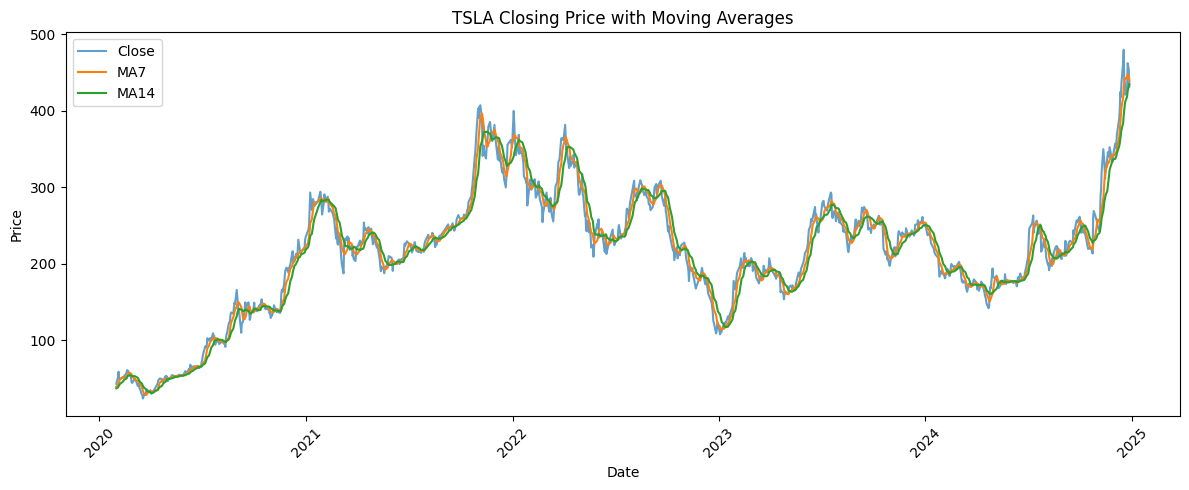

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], label='Close', alpha=0.7)
plt.plot(df['Date'], df['MA7'], label='MA7')
plt.plot(df['Date'], df['MA14'], label='MA14')
plt.title('TSLA Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation
The moving average plot shows that both MA7 and MA14 follow the overall closing price trend closely.  
MA7 reacts faster to short-term price changes, while MA14 is smoother and reflects medium-term trends.  
During periods of rapid price increase or decline, MA7 responds more quickly than MA14, which is consistent with the nature of short-term moving averages.  

This suggests that moving averages provide useful trend-related information and can serve as important technical indicators for stock movement prediction.

## 3.4 Correlation Heatmap

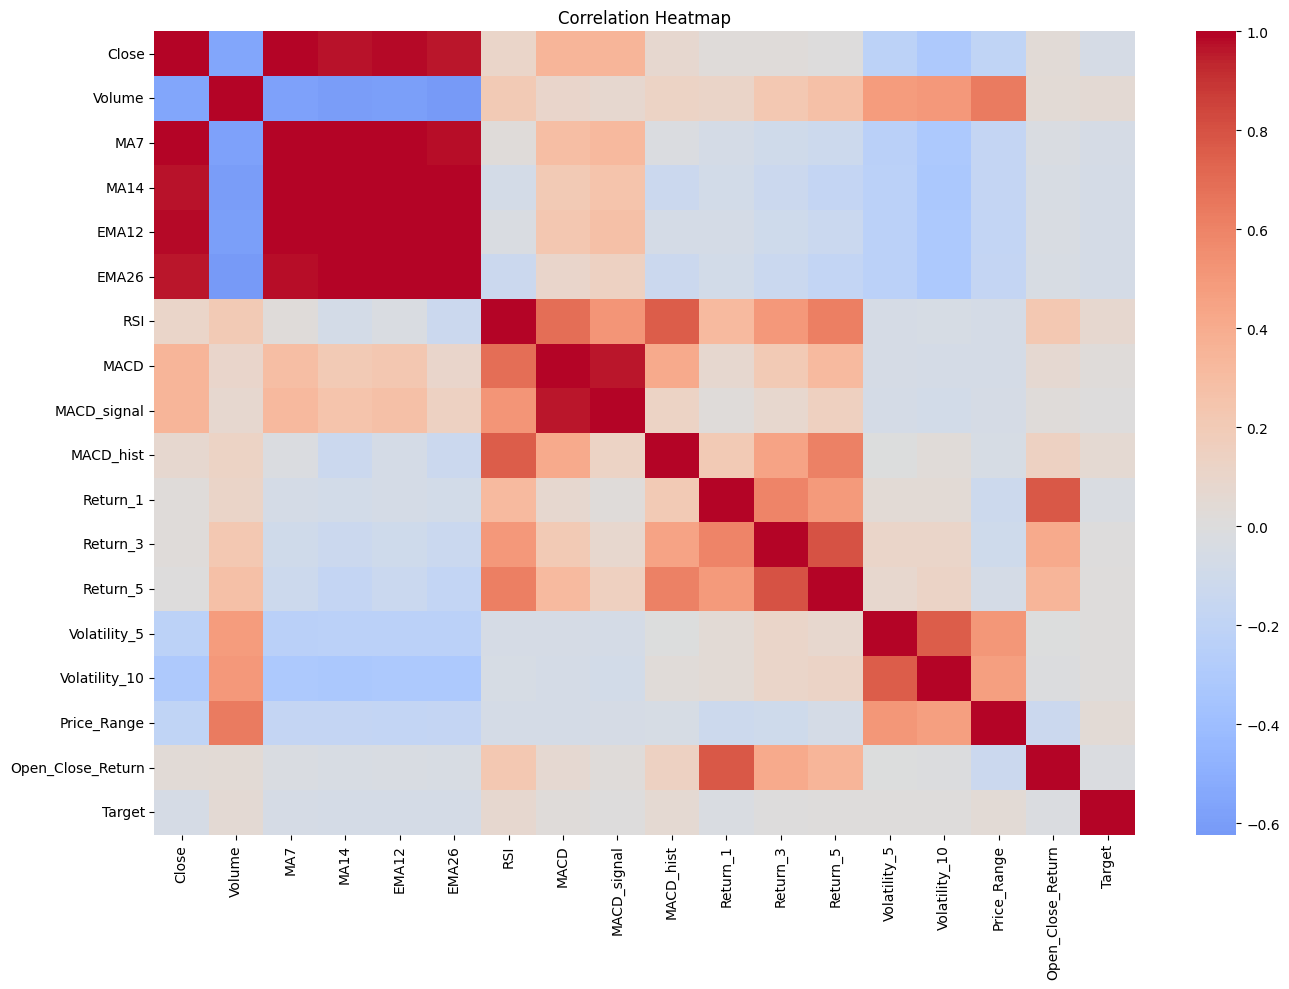

In [21]:
correlation_columns = [
    'Close', 'Volume', 'MA7', 'MA14', 'EMA12', 'EMA26',
    'RSI', 'MACD', 'MACD_signal', 'MACD_hist',
    'Return_1', 'Return_3', 'Return_5',
    'Volatility_5', 'Volatility_10',
    'Price_Range', 'Open_Close_Return',
    'Target'
]

corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Interpretation
The correlation heatmap shows that Close, MA7, and MA14 are highly positively correlated, which is expected because moving averages are derived from closing prices.  
Volume has a moderate negative correlation with Close, MA7, and MA14, suggesting that trading volume does not move in the same direction as price consistently.  
RSI and MACD show a moderate positive correlation, indicating that both indicators capture certain aspects of market momentum.  

The correlations between Target and the technical indicators are relatively weak, which suggests that next-day stock movement direction cannot be explained by a single feature alone.  
This supports the need to combine multiple technical and sentiment-based features in the prediction model.

### EDA Summary
The exploratory data analysis shows that Tesla stock exhibits strong volatility and dynamic price changes over time.  
The target variable is relatively balanced, making it suitable for binary classification.  
Technical indicators such as MA7, MA14, RSI, and MACD capture useful trend and momentum information, but their individual relationships with the target are relatively weak.  

Therefore, relying only on price-based technical indicators may be insufficient for accurate next-day movement prediction.  
This provides motivation for incorporating sentiment features in the next stage of the project.

# 4. Sentiment Data Preparation

## 4.1 Load Text Dataset

In [22]:
import pandas as pd
import requests
import time

# Load the original Kaggle CSV dataset (historical source: 2020-2022)
news_df_1 = pd.read_csv(RESOLVED_PATHS['sample_news'])

print("News dataset 1 shape:", news_df_1.shape)
print(news_df_1.head())
print(news_df_1.columns)

# =========================
# Alpha Vantage settings
# =========================

import os

from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
ALPHAVANTAGE_API_KEY = user_secrets.get_secret("ALPHAVANTAGE_API_KEY")
BASE_URL = "https://www.alphavantage.co/query"

if not ALPHAVANTAGE_API_KEY:
    raise ValueError("Alpha Vantage API key is missing.")
    
def fetch_alpha_vantage_news(api_key, ticker, time_from, time_to, limit=1000, sort="EARLIEST"):
    params = {
        "function": "NEWS_SENTIMENT",
        "tickers": ticker,
        "time_from": time_from,
        "time_to": time_to,
        "sort": sort,
        "limit": limit,
        "apikey": api_key
    }

    response = requests.get(BASE_URL, params=params, timeout=30)
    response.raise_for_status()

    payload = response.json()

    # Handle common Alpha Vantage API messages
    if "Error Message" in payload:
        raise ValueError(f"Alpha Vantage error: {payload['Error Message']}")
    if "Information" in payload:
        raise ValueError(f"Alpha Vantage information: {payload['Information']}")
    if "Note" in payload:
        raise ValueError(f"Alpha Vantage note: {payload['Note']}")

    return payload

# =========================
# Choose time range
# =========================
# First test with a small range:
month_periods = pd.period_range(start="2023-01", end="2024-12", freq="M")

# After successful test, change to:
# month_periods = pd.period_range(start="2023-01", end="2024-12", freq="M")

alpha_rows = []
alpha_log = []

for period in month_periods:
    start_ts = period.to_timestamp(how='start').strftime("%Y%m%dT%H%M")
    end_ts = period.to_timestamp(how='end').strftime("%Y%m%dT%H%M")

    payload = fetch_alpha_vantage_news(
        api_key=ALPHAVANTAGE_API_KEY,
        ticker="TSLA",
        time_from=start_ts,
        time_to=end_ts,
        limit=1000,
        sort="EARLIEST"
    )

    articles = payload.get("feed", [])

    alpha_log.append({
        "month": str(period),
        "time_from": start_ts,
        "time_to": end_ts,
        "article_count": len(articles)
    })

    for article in articles:
        alpha_rows.append({
            "date": article.get("time_published"),
            "title": article.get("title"),
            "summary": article.get("summary"),
            "source": article.get("source"),
            "source_domain": article.get("source_domain"),
            "url": article.get("url"),
            "overall_sentiment_score": article.get("overall_sentiment_score"),
            "overall_sentiment_label": article.get("overall_sentiment_label"),
            "query_tag": "alphavantage_tsla"
        })

    # small pause for safety
    time.sleep(1)

news_df_2 = pd.DataFrame(alpha_rows)
alpha_log_df = pd.DataFrame(alpha_log)

print("\nAlpha Vantage monthly fetch log:")
print(alpha_log_df)

print("\nNews dataset 2 shape:", news_df_2.shape)
print(news_df_2.head())
print(news_df_2.columns)

News dataset 1 shape: (2486, 3)
  company        date                                              title
0    TSLA  2020-01-15  Elon Musk stands to get even richer if Tesla’s...
1    TSLA  2020-01-30  Elon Musk: 'I really didn't want to be CEO of ...
2    TSLA  2020-01-21  Tesla Created Demand for Electric Cars, But On...
3    TSLA  2020-01-15  Elon Musk Nears Record $346 Million Pay As Tes...
4    TSLA  2020-01-24  Elon Musk’s Net Worth Surges $1.7 Billion As T...
Index(['company', 'date', 'title'], dtype='object')

Alpha Vantage monthly fetch log:
      month      time_from        time_to  article_count
0   2023-01  20230101T0000  20230131T2359             56
1   2023-02  20230201T0000  20230228T2359             59
2   2023-03  20230301T0000  20230331T2359             53
3   2023-04  20230401T0000  20230430T2359             29
4   2023-05  20230501T0000  20230531T2359             31
5   2023-06  20230601T0000  20230630T2359             37
6   2023-07  20230701T0000  20230731T2359    

In [23]:
RAW_DIR.mkdir(parents=True, exist_ok=True)
news_df_2.to_csv(RAW_DIR / 'alphavantage_news_2023_2024_raw.csv', index=False)
alpha_log_path = LOG_DIR / 'alphavantage_fetch_log.csv'
alpha_log_path.parent.mkdir(parents=True, exist_ok=True)
alpha_log_df.to_csv(alpha_log_path, index=False)

# Refresh resolved paths after new artifacts are written
RESOLVED_PATHS = {k: first_existing(v) for k, v in PATHS.items()}

print("Raw Alpha Vantage news saved.")
print("Refreshed raw_alpha_news path:", RESOLVED_PATHS['raw_alpha_news'])


Raw Alpha Vantage news saved.


### Explanation
This step loads two Tesla-related news sources.
The first source is a Kaggle CSV dataset covering 2020–2022, while the second source is fetched from the Alpha Vantage NEWS_SENTIMENT API to cover 2023–2024.
Both datasets are inspected before merging.

## 4.2 Merge and Clean News Data

In [24]:
import re
import pandas as pd

def normalize_title(text):
    text = str(text).strip().lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def parse_alpha_vantage_timestamp(ts):
    ts = str(ts)
    for fmt in ("%Y%m%dT%H%M%S", "%Y%m%dT%H%M"):
        try:
            return pd.to_datetime(ts, format=fmt, errors='raise')
        except:
            pass
    return pd.NaT

# =========================
# Rebuild dataset 1: Kaggle CSV
# =========================
news_df_1 = news_df_1[['date', 'title']].copy()
news_df_1['source'] = 'kaggle_csv'
news_df_1['query_tag'] = 'kaggle_history'
news_df_1['publisher'] = None
news_df_1['source_domain'] = None
news_df_1['url'] = None
news_df_1['summary'] = None
news_df_1['overall_sentiment_score'] = None
news_df_1['overall_sentiment_label'] = None

# Keep raw date for reference
news_df_1['raw_date'] = news_df_1['date'].astype(str)

# Kaggle data only has date, no intraday time
news_df_1['published_at'] = pd.to_datetime(news_df_1['date'], errors='coerce')
news_df_1['has_intraday_time'] = False

# =========================
# Rebuild dataset 2: Alpha Vantage
# =========================
news_df_2 = news_df_2[
    [
        'date', 'title', 'summary', 'source', 'source_domain',
        'url', 'overall_sentiment_score', 'overall_sentiment_label', 'query_tag'
    ]
].copy()

news_df_2['publisher'] = news_df_2['source']
news_df_2['raw_date'] = news_df_2['date'].astype(str)

# Alpha Vantage has intraday time
news_df_2['published_at'] = news_df_2['date'].apply(parse_alpha_vantage_timestamp)

# Alpha Vantage timestamps are effectively timestamp strings with time information
# Convert to New York local naive datetime for market-time alignment
news_df_2['published_at'] = (
    pd.to_datetime(news_df_2['published_at'], errors='coerce', utc=True)
      .dt.tz_convert('America/New_York')
      .dt.tz_localize(None)
)

news_df_2['has_intraday_time'] = True

# Mark source name clearly
news_df_2['source'] = 'alphavantage_api'

print("Before merge:")
print("news_df_1 shape:", news_df_1.shape)
print("news_df_2 shape:", news_df_2.shape)
print("news_df_2 max published_at:", news_df_2['published_at'].max())

# =========================
# Keep consistent columns
# =========================
common_columns = [
    'source', 'query_tag', 'publisher', 'source_domain', 'url',
    'summary', 'overall_sentiment_score', 'overall_sentiment_label',
    'raw_date', 'published_at', 'has_intraday_time', 'title'
]

news_df_1 = news_df_1[common_columns]
news_df_2 = news_df_2[common_columns]

# Merge both datasets
news_df = pd.concat([news_df_1, news_df_2], ignore_index=True)

# Remove missing essentials
news_df = news_df.dropna(subset=['published_at', 'title']).copy()

# Clean title formatting
news_df['title'] = news_df['title'].astype(str).str.strip()
news_df['normalized_title'] = news_df['title'].apply(normalize_title)
news_df['published_calendar_date'] = pd.to_datetime(news_df['published_at']).dt.date

# Sort before deduplication
news_df = news_df.sort_values(['published_at', 'source']).reset_index(drop=True)

# Remove duplicates on same calendar date + normalized title
news_df = news_df.drop_duplicates(
    subset=['published_calendar_date', 'normalized_title'],
    keep='first'
).reset_index(drop=True)

print("\nAfter cleaning:", news_df.shape)
print("Min published_at:", news_df['published_at'].min())
print("Max published_at:", news_df['published_at'].max())

print("\nColumns in news_df:")
print(news_df.columns.tolist())

print("\nSource distribution:")
print(news_df['source'].value_counts())

print(news_df.head(10))
print(news_df.tail(10))

Before merge:
news_df_1 shape: (2486, 13)
news_df_2 shape: (935, 13)
news_df_2 max published_at: 2024-12-31 08:55:00

After cleaning: (3414, 14)
Min published_at: 2020-01-01 00:00:00
Max published_at: 2024-12-31 08:55:00

Columns in news_df:
['source', 'query_tag', 'publisher', 'source_domain', 'url', 'summary', 'overall_sentiment_score', 'overall_sentiment_label', 'raw_date', 'published_at', 'has_intraday_time', 'title', 'normalized_title', 'published_calendar_date']

Source distribution:
source
kaggle_csv          2486
alphavantage_api     928
Name: count, dtype: int64
       source       query_tag publisher source_domain   url summary  \
0  kaggle_csv  kaggle_history      None          None  None    None   
1  kaggle_csv  kaggle_history      None          None  None    None   
2  kaggle_csv  kaggle_history      None          None  None    None   
3  kaggle_csv  kaggle_history      None          None  None    None   
4  kaggle_csv  kaggle_history      None          None  None    None

/tmp/ipykernel_57/87740856.py:85: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  news_df = pd.concat([news_df_1, news_df_2], ignore_index=True)


In [25]:
print("Check required columns for downstream steps:")
required_cols = ['published_at', 'has_intraday_time', 'raw_date', 'title']
for col in required_cols:
    print(col, "->", col in news_df.columns)

print("\nNews count by year:")
print(pd.to_datetime(news_df['published_at']).dt.year.value_counts().sort_index())

Check required columns for downstream steps:
published_at -> True
has_intraday_time -> True
raw_date -> True
title -> True

News count by year:
published_at
2020    681
2021    850
2022    913
2023    471
2024    499
Name: count, dtype: int64


In [26]:
news_df['year'] = pd.to_datetime(news_df['published_at']).dt.year

print("News count by year:")
print(news_df['year'].value_counts().sort_index())

print("\nNews count by query tag:")
print(news_df['query_tag'].value_counts(dropna=False))

print("\n2023-2024 coverage check:")
preview_cols = ['published_at', 'title']
if 'publisher' in news_df.columns:
    preview_cols.append('publisher')

print(
    news_df[news_df['year'].isin([2023, 2024])][preview_cols].head(20)
)

News count by year:
year
2020    681
2021    850
2022    913
2023    471
2024    499
Name: count, dtype: int64

News count by query tag:
query_tag
kaggle_history       2486
alphavantage_tsla     928
Name: count, dtype: int64

2023-2024 coverage check:
            published_at                                              title  \
2444 2023-01-01 00:00:00  Lucid Has an Uphill Battle 2023 to Catch Tesla...   
2445 2023-01-01 23:51:49  Tesla Says Company Sold a Record 1.3 Million V...   
2446 2023-01-02 00:00:00  How Elon Musk lost $130 billion in a year - EL...   
2447 2023-01-02 00:00:00  Elon Musk’s Tesla Comes Up Short of 2022 Deliv...   
2448 2023-01-02 00:00:00  Warren Buffett's Best Quotes of 2022: Stocks, ...   
2449 2023-01-02 00:00:00  Tesla could still fall more than 60% if it's v...   
2450 2023-01-02 23:30:25           Better Chinese EV Stock: Nio vs. Li Auto   
2451 2023-01-02 23:47:42  Tesla stock suffers worst-ever year in 2022 de...   
2452 2023-01-03 00:00:00  Tesla share

### Explanation
This step merges the Kaggle historical news dataset and the Alpha Vantage news dataset into one unified dataset.  
After merging, missing values and duplicate news titles on the same calendar date are removed.  
The cleaned dataset provides a broader Tesla news collection for sentiment analysis across 2020–2024.

## 4.3 Prepare Text for Sentiment Analysis

In [27]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^A-Za-z0-9\s.,!?$%-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Prepare title + summary text for richer sentiment input
news_df['title'] = news_df['title'].fillna('').astype(str)
news_df['summary'] = news_df['summary'].fillna('').astype(str)

news_df['clean_title'] = news_df['title'].apply(clean_text)
news_df['clean_summary'] = news_df['summary'].apply(clean_text)

news_df['text_for_sentiment'] = (
    news_df['clean_title'].fillna('') + '. ' + news_df['clean_summary'].fillna('')
).str.strip()

news_df['text_for_sentiment'] = news_df['text_for_sentiment'].str.replace(r'^\.\s*', '', regex=True)
news_df['text_for_sentiment'] = news_df['text_for_sentiment'].str.replace(r'\s+', ' ', regex=True).str.strip()

print(news_df[['title', 'summary', 'clean_title', 'clean_summary', 'text_for_sentiment']].head(10))
print("\nShape after text preparation:", news_df.shape)

                                               title summary  \
0  Tesla updates 2020 Supercharger map with new l...           
1  Musk’s Moment of Truth Arrives With Made-in-Ch...           
2  Elon Musk Heads to Shanghai to Deliver His Fir...           
3  Elon Musk’s moment of truth arrives with made-...           
4  How Elon Musk Built a Tesla Factory in China i...           
5  Elon Musk says will design a future Tesla car ...           
6  Tesla moves into China as shares double and ma...           
7  Venture capitalist compares Elon Musk's Tesla ...           
8  With Tesla at all-time highs, Cramer and other...           
9  Elon Musk dances to celebrate first deliveries...           

                                         clean_title clean_summary  \
0  Tesla updates 2020 Supercharger map with new l...                 
1  Musk s Moment of Truth Arrives With Made-in-Ch...                 
2  Elon Musk Heads to Shanghai to Deliver His Fir...                 
3  Elon Musk s 

### Explanation
This step prepares richer text input for sentiment analysis by cleaning both the news title and the news summary.  
The cleaned title and summary are combined into a new field called `text_for_sentiment`, which provides more context than using the title alone.

## 4.4 Apply FinBERT Sentiment Analysis

> Dependency note: install `transformers` and `torch` via `requirements.txt` (or Kaggle environment setup) before running FinBERT cells.

This notebook intentionally avoids Jupyter magic install commands for safer script export.

In [29]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

finbert_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer
)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [30]:
sample_results = finbert_pipeline([news_df['text_for_sentiment'].iloc[0]], truncation=True)
print(sample_results)

[{'label': 'neutral', 'score': 0.8278459906578064}]


In [31]:
def batch_sentiment_analysis(text_list, batch_size=32):
    all_results = []
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        results = finbert_pipeline(batch, truncation=True)
        all_results.extend(results)
    return all_results

# Use the richer title + summary text instead of title only
sentiment_results = batch_sentiment_analysis(news_df['text_for_sentiment'].tolist(), batch_size=32)

news_df['sentiment_label'] = [item['label'] for item in sentiment_results]
news_df['sentiment_confidence'] = [item['score'] for item in sentiment_results]

print(news_df[['text_for_sentiment', 'sentiment_label', 'sentiment_confidence']].head(10))
print(news_df.shape)

                                  text_for_sentiment sentiment_label  \
0  Tesla updates 2020 Supercharger map with new l...         neutral   
1  Musk s Moment of Truth Arrives With Made-in-Ch...         neutral   
2  Elon Musk Heads to Shanghai to Deliver His Fir...         neutral   
3  Elon Musk s moment of truth arrives with made-...         neutral   
4  How Elon Musk Built a Tesla Factory in China i...         neutral   
5  Elon Musk says will design a future Tesla car ...         neutral   
6  Tesla moves into China as shares double and ma...        positive   
7  Venture capitalist compares Elon Musk s Tesla ...         neutral   
8  With Tesla at all-time highs, Cramer and other...        positive   
9  Elon Musk dances to celebrate first deliveries...         neutral   

   sentiment_confidence  
0              0.827846  
1              0.853271  
2              0.911010  
3              0.905418  
4              0.930739  
5              0.786596  
6              0.661549  

### Explanation
This step applies FinBERT sentiment analysis to the combined `text_for_sentiment` field in batches.  
Each news item is classified as positive, negative, or neutral, and a confidence score is assigned.

## 4.5 Aggregate Daily Sentiment Features

In [32]:
import numpy as np

label_to_score = {
    'positive': 1,
    'neutral': 0,
    'negative': -1
}

news_df['sentiment_score'] = news_df['sentiment_label'].map(label_to_score)

# Additional news-level sentiment features
news_df['weighted_item_score'] = news_df['sentiment_score'] * news_df['sentiment_confidence']
news_df['strong_positive_flag'] = (
    (news_df['sentiment_label'] == 'positive') &
    (news_df['sentiment_confidence'] >= 0.90)
).astype(int)

news_df['strong_negative_flag'] = (
    (news_df['sentiment_label'] == 'negative') &
    (news_df['sentiment_confidence'] >= 0.90)
).astype(int)

# Use the raw trading calendar saved before stock-data cleaning
trading_index = raw_trading_index

def assign_effective_trading_date(published_at, has_intraday_time, trading_index, market_close_hour=16):
    """
    Rules:
    1. If the news date is a trading day and timestamp is before market close -> assign to same trading day
    2. If timestamp is after market close -> assign to next trading day
    3. If it is weekend / holiday -> assign to next available trading day
    4. If intraday time is unavailable -> use the stated calendar date,
       and if that date is not a trading day, move to the next trading day
    """
    if pd.isna(published_at):
        return pd.NaT

    published_ts = pd.Timestamp(published_at)
    published_day = published_ts.normalize()

    if has_intraday_time:
        if published_ts.hour >= market_close_hour:
            anchor_day = published_day + pd.Timedelta(days=1)
        else:
            anchor_day = published_day
    else:
        anchor_day = published_day

    pos = trading_index.searchsorted(anchor_day, side='left')

    if pos >= len(trading_index):
        return pd.NaT

    return trading_index[pos]

news_df['Effective_Date'] = news_df.apply(
    lambda row: assign_effective_trading_date(
        row['published_at'],
        row['has_intraday_time'],
        trading_index
    ),
    axis=1
)

# Remove news outside stock-date coverage
news_df = news_df.dropna(subset=['Effective_Date']).copy()

def aggregate_daily_sentiment(df_input, prefix=''):
    daily_df = df_input.groupby('Effective_Date').agg(
        daily_sentiment_score=('sentiment_score', 'mean'),
        weighted_sentiment_score=('weighted_item_score', 'mean'),

        positive_ratio=('sentiment_label', lambda x: (x == 'positive').mean()),
        negative_ratio=('sentiment_label', lambda x: (x == 'negative').mean()),
        neutral_ratio=('sentiment_label', lambda x: (x == 'neutral').mean()),

        positive_count=('sentiment_label', lambda x: (x == 'positive').sum()),
        negative_count=('sentiment_label', lambda x: (x == 'negative').sum()),
        neutral_count=('sentiment_label', lambda x: (x == 'neutral').sum()),

        news_count=('sentiment_label', 'count'),
        avg_confidence=('sentiment_confidence', 'mean'),
        sentiment_std=('sentiment_score', 'std'),

        strong_positive_count=('strong_positive_flag', 'sum'),
        strong_negative_count=('strong_negative_flag', 'sum')
    ).reset_index()

    daily_df['sentiment_std'] = daily_df['sentiment_std'].fillna(0)
    daily_df['net_sentiment'] = daily_df['positive_ratio'] - daily_df['negative_ratio']

    daily_df = daily_df.rename(columns={'Effective_Date': 'Date'})
    daily_df['Date'] = pd.to_datetime(daily_df['Date']).dt.date

    if prefix:
        rename_map = {
            col: f'{prefix}{col}'
            for col in daily_df.columns
            if col != 'Date'
        }
        daily_df = daily_df.rename(columns=rename_map)

    return daily_df

# A) Daily sentiment using ALL news
daily_sentiment_all = aggregate_daily_sentiment(news_df, prefix='')

# B) Daily sentiment using ONLY timestamped news
news_df_intraday = news_df[news_df['has_intraday_time'] == True].copy()
daily_sentiment_intraday = aggregate_daily_sentiment(news_df_intraday, prefix='intraday_')

# Merge both daily tables
daily_sentiment = pd.merge(
    daily_sentiment_all,
    daily_sentiment_intraday,
    on='Date',
    how='left'
)

# Daily flag: whether this trading day has at least one timestamped news item
daily_sentiment['intraday_news_available'] = (
    daily_sentiment['intraday_news_count'].notna().astype(int)
)

# Optional diagnostic ratio
daily_sentiment['intraday_news_share'] = (
    daily_sentiment['intraday_news_count'].fillna(0) /
    daily_sentiment['news_count'].replace(0, np.nan)
).fillna(0)

print(daily_sentiment.head(10))
print(daily_sentiment.shape)
print("Min date:", daily_sentiment['Date'].min())
print("Max date:", daily_sentiment['Date'].max())

print("\nDaily sentiment columns:")
print(daily_sentiment.columns.tolist())

print("\nSample mapped news records:")
print(
    news_df[['source', 'query_tag', 'raw_date', 'published_at', 'has_intraday_time',
             'Effective_Date', 'sentiment_label', 'sentiment_confidence', 'title']].head(15)
)

print("\nTimestamped-news coverage by source:")
print(news_df.groupby(['source', 'has_intraday_time']).size())

         Date  daily_sentiment_score  weighted_sentiment_score  \
0  2020-01-02               0.000000                  0.000000   
1  2020-01-06               0.000000                  0.000000   
2  2020-01-07               0.153846                  0.097781   
3  2020-01-08               0.000000                  0.000000   
4  2020-01-09               0.333333                  0.236247   
5  2020-01-10              -0.250000                 -0.220790   
6  2020-01-13               0.000000                  0.000000   
7  2020-01-14               0.500000                  0.461635   
8  2020-01-15               0.750000                  0.536258   
9  2020-01-16               0.500000                  0.328560   

   positive_ratio  negative_ratio  neutral_ratio  positive_count  \
0        0.000000            0.00       1.000000               0   
1        0.000000            0.00       1.000000               0   
2        0.153846            0.00       0.846154               2   
3

In [33]:
print("Examples of weekend / after-hours mapping check:")

sample_check = news_df[['source', 'raw_date', 'published_at', 'has_intraday_time', 'Effective_Date', 'title']].copy()

# Show some records where effective date is different from published calendar date
sample_check['published_calendar_date'] = pd.to_datetime(sample_check['published_at']).dt.date
sample_check['effective_calendar_date'] = pd.to_datetime(sample_check['Effective_Date']).dt.date

changed_mapping = sample_check[
    sample_check['published_calendar_date'] != sample_check['effective_calendar_date']
]

print(changed_mapping.head(20))
print("Number of remapped records:", len(changed_mapping))

Examples of weekend / after-hours mapping check:
         source    raw_date published_at  has_intraday_time Effective_Date  \
0    kaggle_csv  2020-01-01   2020-01-01              False     2020-01-02   
1    kaggle_csv  2020-01-04   2020-01-04              False     2020-01-06   
26   kaggle_csv  2020-01-11   2020-01-11              False     2020-01-13   
41   kaggle_csv  2020-01-18   2020-01-18              False     2020-01-21   
61   kaggle_csv  2020-01-25   2020-01-25              False     2020-01-27   
62   kaggle_csv  2020-01-26   2020-01-26              False     2020-01-27   
69   kaggle_csv  2020-02-01   2020-02-01              False     2020-02-03   
70   kaggle_csv  2020-02-01   2020-02-01              False     2020-02-03   
71   kaggle_csv  2020-02-02   2020-02-02              False     2020-02-03   
89   kaggle_csv  2020-02-08   2020-02-08              False     2020-02-10   
90   kaggle_csv  2020-02-09   2020-02-09              False     2020-02-10   
101  kaggle_csv

### Explanation
This step aggregates individual news-level sentiment results into daily sentiment features.  
The resulting variables summarize the overall sentiment condition of each day, including average sentiment score, sentiment ratios, daily news volume, and average confidence score.  
These daily sentiment features will later be merged with the stock dataset for prediction modeling.

## 4.6 Save Processed Sentiment Dataset

## 4.7 Alignment Audit for Leakage Prevention

### Time-point definition
This project predicts **next trading-day** Tesla movement using information available **before the target movement**.

Audit purpose:
- verify stock date, news published date, and effective trading date mapping
- verify next-day target relationship
- summarize weekend and after-hours remapping counts
- provide auditable evidence file for supervisor review


In [ ]:
# Alignment audit summary (does not change modeling logic)
audit_df = news_df[[
    'source', 'title', 'published_at', 'published_calendar_date',
    'has_intraday_time', 'Effective_Date'
]].copy()

audit_df['published_date'] = pd.to_datetime(audit_df['published_at']).dt.date
audit_df['effective_date'] = pd.to_datetime(audit_df['Effective_Date']).dt.date
audit_df['published_weekday'] = pd.to_datetime(audit_df['published_at']).dt.dayofweek  # 0=Mon
audit_df['effective_weekday'] = pd.to_datetime(audit_df['Effective_Date']).dt.dayofweek

audit_df['is_weekend_published'] = audit_df['published_weekday'].isin([5, 6])
audit_df['was_remapped_to_next_date'] = audit_df['effective_date'] > audit_df['published_date']

# After-hours proxy: only for rows with intraday timestamp
market_close_hour = 16
audit_df['published_hour'] = pd.to_datetime(audit_df['published_at']).dt.hour
audit_df['is_after_hours'] = audit_df['has_intraday_time'] & (audit_df['published_hour'] >= market_close_hour)

summary = {
    'total_news_rows': len(audit_df),
    'weekend_published_rows': int(audit_df['is_weekend_published'].sum()),
    'after_hours_rows_estimated': int(audit_df['is_after_hours'].sum()),
    'remapped_rows_total': int(audit_df['was_remapped_to_next_date'].sum()),
    'weekend_remapped_rows': int((audit_df['is_weekend_published'] & audit_df['was_remapped_to_next_date']).sum()),
    'after_hours_remapped_rows': int((audit_df['is_after_hours'] & audit_df['was_remapped_to_next_date']).sum())
}

print('Alignment audit summary:')
for k,v in summary.items():
    print(f' - {k}: {v}')

# Save auditable sample and full file
audit_export_cols = [
    'source', 'published_at', 'published_date', 'effective_date',
    'has_intraday_time', 'published_hour',
    'is_weekend_published', 'is_after_hours', 'was_remapped_to_next_date', 'title'
]
audit_out = audit_df[audit_export_cols].sort_values('published_at').reset_index(drop=True)
audit_path = RESULTS_DIR / 'alignment_audit.csv'
audit_out.to_csv(audit_path, index=False)
print('Saved alignment audit to:', audit_path)
print(audit_out.head(10))

In [ ]:
daily_sentiment.to_csv(PROCESSED_DIR / 'tesla_daily_sentiment_updated.csv', index=False)

print("Updated sentiment dataset saved successfully.")

import os
if IS_KAGGLE and Path('/kaggle/working').exists():
    print('Kaggle working dir files:', os.listdir('/kaggle/working'))
else:
    output_dir = PROCESSED_DIR if PROCESSED_DIR.exists() else RESULTS_DIR
    print(f'Local output dir files ({output_dir}):', os.listdir(output_dir) if output_dir.exists() else 'DIR NOT FOUND')

### Explanation
This step saves the processed daily sentiment dataset for later use.  
The saved file will be merged with the stock price and technical indicator dataset in the feature fusion stage.

# 5. Feature Fusion

## 5.1 Load Processed Datasets

In [ ]:
stock_df = pd.read_csv(RESOLVED_PATHS['processed_stock'])
sentiment_df = pd.read_csv(RESOLVED_PATHS['daily_sentiment'])

print("Stock dataset shape:", stock_df.shape)
print("Sentiment dataset shape:", sentiment_df.shape)

print(stock_df.head())
print(sentiment_df.head())

### Explanation
This step loads the processed stock dataset and the updated daily sentiment dataset.  
The sentiment dataset now includes sentiment information generated from both the original Tesla news dataset and the additional RSS-based news source.  
The purpose is to confirm that both datasets are available and ready for feature fusion.

## 5.2 Standardize Date Format

In [ ]:
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.date
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date']).dt.date

print(stock_df['Date'].head())
print(sentiment_df['Date'].head())

### Explanation
This step standardizes the date format in both datasets to ensure consistent merging.  
Since feature fusion is performed at the daily level, both stock and sentiment data must use the same date representation.

## 5.3 Merge Stock and Sentiment Data

In [ ]:
fused_df = pd.merge(
    stock_df,
    sentiment_df,
    on='Date',
    how='left'
)

print("Fused dataset shape:", fused_df.shape)
print(fused_df.head())

### Explanation
This step merges the stock dataset with the daily sentiment dataset using the Date column.  
A left join is applied so that all stock trading days are retained, even if some dates do not have corresponding news records.

## 5.4 Handle Missing Sentiment Values

In [ ]:
import numpy as np

sentiment_columns = [
    'daily_sentiment_score',
    'weighted_sentiment_score',
    'positive_ratio',
    'negative_ratio',
    'neutral_ratio',
    'positive_count',
    'negative_count',
    'neutral_count',
    'news_count',
    'avg_confidence',
    'sentiment_std',
    'strong_positive_count',
    'strong_negative_count',
    'net_sentiment'
]

intraday_sentiment_columns = [
    'intraday_daily_sentiment_score',
    'intraday_weighted_sentiment_score',
    'intraday_positive_ratio',
    'intraday_negative_ratio',
    'intraday_neutral_ratio',
    'intraday_positive_count',
    'intraday_negative_count',
    'intraday_neutral_count',
    'intraday_news_count',
    'intraday_avg_confidence',
    'intraday_sentiment_std',
    'intraday_strong_positive_count',
    'intraday_strong_negative_count',
    'intraday_net_sentiment'
]

# 1 = there is at least one news record on that trading day
# 0 = no news record matched to that trading day
fused_df['news_available'] = fused_df['news_count'].notna().astype(int)

# Optional extra flag for readability
fused_df['no_news_flag'] = (fused_df['news_available'] == 0).astype(int)

# Intraday-only daily coverage flag
fused_df['intraday_news_available'] = fused_df['intraday_news_available'].fillna(0).astype(int)

# Fill missing aggregated sentiment values with 0
for col in sentiment_columns + intraday_sentiment_columns:
    fused_df[col] = fused_df[col].fillna(0)

# Fill optional diagnostic ratio
fused_df['intraday_news_share'] = fused_df['intraday_news_share'].fillna(0)

# Convert count-like columns to integers
count_columns = [
    'positive_count',
    'negative_count',
    'neutral_count',
    'news_count',
    'strong_positive_count',
    'strong_negative_count'
]

intraday_count_columns = [
    'intraday_positive_count',
    'intraday_negative_count',
    'intraday_neutral_count',
    'intraday_news_count',
    'intraday_strong_positive_count',
    'intraday_strong_negative_count'
]

for col in count_columns + intraday_count_columns:
    fused_df[col] = fused_df[col].astype(int)

print("Missing values after handling:")
print(
    fused_df[
        sentiment_columns +
        intraday_sentiment_columns +
        ['news_available', 'no_news_flag', 'intraday_news_available', 'intraday_news_share']
    ].isnull().sum()
)

print("\nRows with full-news signal:")
print(
    fused_df.loc[fused_df['news_available'] == 1,
                 ['Date', 'weighted_sentiment_score', 'net_sentiment',
                  'negative_ratio', 'news_count', 'news_available']].head(10)
)

print("\nRows with timestamped-news signal:")
print(
    fused_df.loc[fused_df['intraday_news_available'] == 1,
                 ['Date', 'intraday_weighted_sentiment_score', 'intraday_net_sentiment',
                  'intraday_negative_ratio', 'intraday_news_count',
                  'intraday_news_available', 'intraday_news_share']].head(10)
)

In [ ]:
# Sort by date before creating time-based sentiment features
fused_df = fused_df.sort_values('Date').reset_index(drop=True).copy()

# Base columns for lag features
lag_base_columns = [
    'weighted_sentiment_score',
    'net_sentiment',
    'news_count',
    'negative_ratio',
    'strong_negative_count',

    'intraday_weighted_sentiment_score',
    'intraday_net_sentiment',
    'intraday_news_count',
    'intraday_negative_ratio',
    'intraday_strong_negative_count'
]

# Create lag features
for col in lag_base_columns:
    for lag in [1, 2, 3]:
        fused_df[f'{col}_lag{lag}'] = fused_df[col].shift(lag)

# Create rolling mean features for score/ratio-type columns
rolling_mean_columns = [
    'weighted_sentiment_score',
    'net_sentiment',
    'negative_ratio',

    'intraday_weighted_sentiment_score',
    'intraday_net_sentiment',
    'intraday_negative_ratio'
]

for col in rolling_mean_columns:
    for window in [3, 5]:
        fused_df[f'{col}_{window}d_mean'] = (
            fused_df[col].rolling(window=window, min_periods=1).mean()
        )

# Create rolling sum features for count-type columns
rolling_sum_columns = [
    'news_count',
    'strong_negative_count',

    'intraday_news_count',
    'intraday_strong_negative_count'
]

for col in rolling_sum_columns:
    for window in [3, 5]:
        fused_df[f'{col}_{window}d_sum'] = (
            fused_df[col].rolling(window=window, min_periods=1).sum()
        )

# Fill lag-feature NaNs with 0
lag_feature_columns = [col for col in fused_df.columns if '_lag' in col]
fused_df[lag_feature_columns] = fused_df[lag_feature_columns].fillna(0)

print("New lag / rolling sentiment features added successfully.")

new_sentiment_feature_columns = [
    col for col in fused_df.columns
    if ('_lag' in col) or ('_3d_' in col) or ('_5d_' in col)
]

print("\nNew sentiment time-based features:")
print(new_sentiment_feature_columns)

print("\nPreview of enhanced sentiment features:")
preview_columns = [
    'Date',
    'weighted_sentiment_score',
    'intraday_weighted_sentiment_score',
    'net_sentiment',
    'intraday_net_sentiment',
    'news_count',
    'intraday_news_count',
    'negative_ratio',
    'intraday_negative_ratio',
    'news_available',
    'intraday_news_available',
    'weighted_sentiment_score_lag1',
    'intraday_weighted_sentiment_score_lag1',
    'news_count_3d_sum',
    'intraday_news_count_3d_sum'
]

print(fused_df[preview_columns].head(10))

### Explanation
After merging, some trading days may not have corresponding news records, resulting in missing sentiment values.  
These missing values are filled with 0 to indicate the absence of Tesla-related news on that day.  
This allows the dataset to preserve all trading days while maintaining a consistent feature structure.

In [ ]:
# =========================
# Phase 1 (Pruned): LR-oriented feature enhancement
# =========================

eps = 1e-8

# 1) Relative intraday structure features
fused_df['close_position_in_day'] = (
    (fused_df['Close'] - fused_df['Low']) /
    ((fused_df['High'] - fused_df['Low']) + eps)
)

fused_df['body_to_range'] = (
    (fused_df['Close'] - fused_df['Open']) /
    ((fused_df['High'] - fused_df['Low']) + eps)
)

# 2) Selected sentiment enhancement features
fused_df['sentiment_surprise_3'] = (
    fused_df['weighted_sentiment_score'] - fused_df['weighted_sentiment_score_3d_mean']
)

fused_df['abnormal_news_flag'] = (
    fused_df['news_count'] > (fused_df['news_count_3d_sum'] / 3)
).astype(int)

# 3) Selected interaction features
fused_df['sentiment_x_volatility5'] = (
    fused_df['weighted_sentiment_score'] * fused_df['Volatility_5']
)

fused_df['net_sentiment_x_news'] = (
    fused_df['net_sentiment'] * fused_df['news_available']
)

phase1_new_feature_columns = [
    'close_position_in_day',
    'body_to_range',
    'sentiment_surprise_3',
    'abnormal_news_flag',
    'sentiment_x_volatility5',
    'net_sentiment_x_news'
]

fused_df[phase1_new_feature_columns] = (
    fused_df[phase1_new_feature_columns]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("Phase 1 pruned features added:")
print(phase1_new_feature_columns)

preview_cols = ['Date'] + phase1_new_feature_columns
print(fused_df[preview_cols].head(10))

## 5.5 Inspect Final Modeling Dataset

In [ ]:
print(fused_df.shape)
print(fused_df.columns)
print(fused_df.head())

In [ ]:
selected_columns = [
    'Date', 'Close', 'Target', 'Next_Day_Return',
    'weighted_sentiment_score', 'net_sentiment',
    'news_count', 'negative_ratio', 'strong_negative_count',
    'news_available',
    'weighted_sentiment_score_lag1',
    'net_sentiment_lag1',
    'weighted_sentiment_score_3d_mean',
    'weighted_sentiment_score_5d_mean',
    'news_count_3d_sum',
    'negative_ratio_3d_mean',
    'strong_negative_count_3d_sum',
    'close_position_in_day',
    'body_to_range',
    'sentiment_surprise_3',
    'abnormal_news_flag',
    'sentiment_x_volatility5',
    'net_sentiment_x_news'
]

print(fused_df[selected_columns].head(15))

### Explanation
This step inspects the final fused dataset to verify that stock features, technical indicators, sentiment features, and the target variable are all included correctly.  
The fused dataset now serves as the final input for predictive modeling.

## 5.6 Save Final Fused Dataset

In [ ]:
fused_df.to_csv(PROCESSED_DIR / 'tsla_fused_dataset.csv', index=False)

print("Final fused dataset saved successfully.")
if IS_KAGGLE and Path('/kaggle/working').exists():
    print('Kaggle working dir files:', os.listdir('/kaggle/working'))
else:
    output_dir = PROCESSED_DIR if PROCESSED_DIR.exists() else RESULTS_DIR
    print(f'Local output dir files ({output_dir}):', os.listdir(output_dir) if output_dir.exists() else 'DIR NOT FOUND')

# 6. Model Training

## 6.1 Load Final Fused Dataset

In [ ]:
fused_df = pd.read_csv(RESOLVED_PATHS['fused_dataset'])

fused_df['Date'] = pd.to_datetime(fused_df['Date'])
fused_df = fused_df.sort_values('Date').reset_index(drop=True)

print(fused_df.shape)
print(fused_df[['Date', 'Target']].head())
print(fused_df[['Date', 'Target']].tail())

### Explanation
This step loads the final fused dataset, which combines stock price data, technical indicators, and sentiment features.  
The dataset will be used as the input for classification model training.

## 6.2 Select Features and Target

In [ ]:
# Raw price-level features are kept only for reference, not for the main LR feature set
raw_price_feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# Existing sentiment features
sentiment_feature_columns = [
    'weighted_sentiment_score',
    'net_sentiment',
    'news_count',
    'negative_ratio',
    'news_available',
    'weighted_sentiment_score_lag1',
    'net_sentiment_lag1',
    'weighted_sentiment_score_3d_mean',
    'weighted_sentiment_score_5d_mean',
    'news_count_3d_sum',
    'negative_ratio_3d_mean',
    'strong_negative_count_3d_sum'
]

# Phase 1 pruned feature groups
phase1_relative_price_columns = [
    'close_position_in_day',
    'body_to_range'
]

phase1_sentiment_enhancement_columns = [
    'sentiment_surprise_3',
    'abnormal_news_flag'
]

phase1_interaction_columns = [
    'sentiment_x_volatility5',
    'net_sentiment_x_news'
]

# Original setup for reference
feature_columns_phase0 = raw_price_feature_columns + technical_columns + sentiment_feature_columns

# Pruned Phase 1 optimized setup for Logistic Regression
feature_columns_phase1 = (
    technical_columns +
    phase1_relative_price_columns +
    sentiment_feature_columns +
    phase1_sentiment_enhancement_columns +
    phase1_interaction_columns
)

selected_feature_set_name = 'Phase1_Pruned_LR_Optimized_NoRawOHLCV'
feature_columns = feature_columns_phase1

X = fused_df[feature_columns].copy()
y = fused_df['Target'].astype(int)

print("Selected feature set:", selected_feature_set_name)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", len(feature_columns))
print("\nFirst 15 selected features:")
print(feature_columns[:15])

### Explanation
This step defines the input features and the target variable for model training.  
Price-based features, technical indicators, and sentiment features are selected as predictors, while the Target column is used as the binary classification label.

## 6.3 Set Up Time-Series Cross-Validation

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

fold_overview = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    fold_overview.append({
        'Fold': fold,
        'Train_Size': len(train_idx),
        'Test_Size': len(test_idx),
        'Train_Start_Date': fused_df.iloc[train_idx]['Date'].min(),
        'Train_End_Date': fused_df.iloc[train_idx]['Date'].max(),
        'Test_Start_Date': fused_df.iloc[test_idx]['Date'].min(),
        'Test_End_Date': fused_df.iloc[test_idx]['Date'].max()
    })

cv_split_df = pd.DataFrame(fold_overview)
print(cv_split_df)

In [ ]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }

def evaluate_model_tscv(model_name, model, X_df, y_series, splitter, scale=False):
    fold_rows = []
    oof_parts = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X_df), start=1):
        X_train_fold = X_df.iloc[train_idx]
        X_test_fold = X_df.iloc[test_idx]
        y_train_fold = y_series.iloc[train_idx]
        y_test_fold = y_series.iloc[test_idx]

        if scale:
            scaler = StandardScaler()
            X_train_input = scaler.fit_transform(X_train_fold)
            X_test_input = scaler.transform(X_test_fold)
        else:
            X_train_input = X_train_fold
            X_test_input = X_test_fold

        fitted_model = clone(model)
        fitted_model.fit(X_train_input, y_train_fold)
        y_pred_fold = fitted_model.predict(X_test_input)

        metric_row = calculate_metrics(y_test_fold, y_pred_fold)
        metric_row['Fold'] = fold
        fold_rows.append(metric_row)

        oof_parts.append(pd.DataFrame({
            'Index': test_idx,
            'True': y_test_fold.values,
            'Pred': y_pred_fold
        }))

    fold_df = pd.DataFrame(fold_rows)
    summary_df = pd.DataFrame([{
        'Model': model_name,
        'Accuracy_Mean': fold_df['Accuracy'].mean(),
        'Accuracy_Std': fold_df['Accuracy'].std(ddof=0),
        'Precision_Mean': fold_df['Precision'].mean(),
        'Precision_Std': fold_df['Precision'].std(ddof=0),
        'Recall_Mean': fold_df['Recall'].mean(),
        'Recall_Std': fold_df['Recall'].std(ddof=0),
        'F1_Mean': fold_df['F1'].mean(),
        'F1_Std': fold_df['F1'].std(ddof=0)
    }])

    oof_df = pd.concat(oof_parts, ignore_index=True).sort_values('Index').reset_index(drop=True)
    return summary_df, fold_df, oof_df

In [ ]:
# =========================
# Phase 2: Select a better Logistic Regression configuration
# using time-series inner CV
# =========================

from sklearn.linear_model import LogisticRegression

lr_param_candidates = [
    {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': None},
    {'C': 0.10, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': None},
    {'C': 1.00, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': None},
    {'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': None},

    {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None},
    {'C': 0.10, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None},
    {'C': 1.00, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None},
    {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None},

    {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': 'balanced'},
    {'C': 0.10, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': 'balanced'},
    {'C': 1.00, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': 'balanced'},
    {'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': 'balanced'},

    {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced'},
    {'C': 0.10, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced'},
    {'C': 1.00, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced'},
    {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced'}
]

inner_tscv = TimeSeriesSplit(n_splits=4)

lr_search_rows = []

for params in lr_param_candidates:
    inner_acc_scores = []
    inner_f1_scores = []

    for train_idx, val_idx in inner_tscv.split(X):
        X_train_inner = X.iloc[train_idx]
        X_val_inner = X.iloc[val_idx]
        y_train_inner = y.iloc[train_idx]
        y_val_inner = y.iloc[val_idx]

        scaler = StandardScaler()
        X_train_inner_scaled = scaler.fit_transform(X_train_inner)
        X_val_inner_scaled = scaler.transform(X_val_inner)

        lr_candidate = LogisticRegression(
            max_iter=2000,
            random_state=42,
            **params
        )

        lr_candidate.fit(X_train_inner_scaled, y_train_inner)
        y_val_pred = lr_candidate.predict(X_val_inner_scaled)

        inner_acc_scores.append(
            accuracy_score(y_val_inner, y_val_pred)
        )
        inner_f1_scores.append(
            f1_score(y_val_inner, y_val_pred, zero_division=0)
        )

    lr_search_rows.append({
        'C': params['C'],
        'penalty': params['penalty'],
        'class_weight': 'None' if params['class_weight'] is None else params['class_weight'],
        'Accuracy_Mean': np.mean(inner_acc_scores),
        'F1_Mean': np.mean(inner_f1_scores)
    })

lr_search_df = pd.DataFrame(lr_search_rows).sort_values(
    ['Accuracy_Mean', 'F1_Mean'],
    ascending=False
).reset_index(drop=True)

best_lr_row = lr_search_df.iloc[0]

best_lr_params = {
    'C': float(best_lr_row['C']),
    'penalty': best_lr_row['penalty'],
    'solver': 'liblinear',
    'class_weight': None if best_lr_row['class_weight'] == 'None' else best_lr_row['class_weight']
}

print("Top LR parameter candidates:")
print(lr_search_df.head(10).round(4))

print("\nSelected best LR parameters for Phase 2:")
print(best_lr_params)

In [ ]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Existing expanding-window splits from TimeSeriesSplit
expanding_splits = list(tscv.split(X))

# Fixed-length rolling window size
# 252 trading days ≈ 1 trading year
rolling_train_window = 252

def make_rolling_splits_from_expanding(base_splits, train_window=252):
    rolling_splits = []

    for train_idx, test_idx in base_splits:
        test_start = test_idx[0]
        train_end = test_start
        train_start = max(0, train_end - train_window)

        rolling_train_idx = np.arange(train_start, train_end)

        if len(rolling_train_idx) == 0:
            continue

        rolling_splits.append((rolling_train_idx, test_idx))

    return rolling_splits

rolling_splits = make_rolling_splits_from_expanding(
    expanding_splits,
    train_window=rolling_train_window
)

def evaluate_model_predefined_splits(model_name, model, X_df, y_series, splits, scale=False):
    fold_rows = []
    oof_rows = []

    for fold_id, (train_idx, test_idx) in enumerate(splits, start=1):
        X_train = X_df.iloc[train_idx].copy()
        X_test = X_df.iloc[test_idx].copy()
        y_train = y_series.iloc[train_idx].copy()
        y_test = y_series.iloc[test_idx].copy()

        fitted_model = clone(model)

        if scale:
            scaler = StandardScaler()
            X_train_input = scaler.fit_transform(X_train)
            X_test_input = scaler.transform(X_test)
        else:
            X_train_input = X_train
            X_test_input = X_test

        fitted_model.fit(X_train_input, y_train)
        y_pred = fitted_model.predict(X_test_input)

        fold_rows.append({
            'Fold': fold_id,
            'Train_Size': len(train_idx),
            'Test_Size': len(test_idx),
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1': f1_score(y_test, y_pred, zero_division=0)
        })

        fold_oof = pd.DataFrame({
            'row_index': test_idx,
            'fold': fold_id,
            'y_true': y_test.values,
            'y_pred': y_pred
        })

        if hasattr(fitted_model, "predict_proba"):
            fold_oof['y_prob'] = fitted_model.predict_proba(X_test_input)[:, 1]

        oof_rows.append(fold_oof)

    folds_df = pd.DataFrame(fold_rows)

    summary_df = pd.DataFrame([{
        'Model': model_name,
        'Accuracy_Mean': folds_df['Accuracy'].mean(),
        'Accuracy_Std': folds_df['Accuracy'].std(ddof=0),
        'Precision_Mean': folds_df['Precision'].mean(),
        'Precision_Std': folds_df['Precision'].std(ddof=0),
        'Recall_Mean': folds_df['Recall'].mean(),
        'Recall_Std': folds_df['Recall'].std(ddof=0),
        'F1_Mean': folds_df['F1'].mean(),
        'F1_Std': folds_df['F1'].std(ddof=0)
    }])

    oof_df = pd.concat(oof_rows, ignore_index=True).sort_values('row_index').reset_index(drop=True)

    return summary_df, folds_df, oof_df

print("Expanding-window folds:")
for i, (train_idx, test_idx) in enumerate(expanding_splits, start=1):
    print(f"Fold {i}: train={len(train_idx)}, test={len(test_idx)}")

print("\nRolling-window folds:")
for i, (train_idx, test_idx) in enumerate(rolling_splits, start=1):
    print(f"Fold {i}: train={len(train_idx)}, test={len(test_idx)}")

In [ ]:
from sklearn.base import clone
import numpy as np
import pandas as pd

# =========================
# Phase 5: Sample reliability weighting / filtering
# =========================

# 1) Distance from the classification boundary
# For this project, the label boundary is TARGET_THRESHOLD
fused_df['boundary_distance'] = np.minimum(
    (fused_df['Next_Day_Return'] - TARGET_THRESHOLD).abs(),
    (fused_df['Next_Day_Return'] + TARGET_THRESHOLD).abs()
)

# 2) Percentile-style scaling for weighting
fused_df['boundary_distance_pct'] = fused_df['boundary_distance'].rank(pct=True)
fused_df['volatility_5_pct'] = fused_df['Volatility_5'].rank(pct=True)

# 3) Reliability weight:
#    - larger weight for higher volatility samples
#    - larger weight for samples farther from the label boundary
fused_df['sample_reliability_weight'] = (
    1.0
    + 0.75 * fused_df['volatility_5_pct']
    + 0.75 * fused_df['boundary_distance_pct']
)

# 4) Filtering rule:
#    remove the samples closest to the boundary (lowest-confidence samples)
boundary_filter_quantile = 0.20
boundary_filter_cutoff = fused_df['boundary_distance'].quantile(boundary_filter_quantile)

fused_df['keep_high_confidence_sample'] = (
    fused_df['boundary_distance'] >= boundary_filter_cutoff
).astype(int)

# Align weights / flags with the current X, y rows
sample_weight_series = fused_df.loc[X.index, 'sample_reliability_weight'].copy()
keep_high_confidence_series = fused_df.loc[X.index, 'keep_high_confidence_sample'].copy()

def evaluate_model_predefined_splits_with_weights(
    model_name,
    model,
    X_df,
    y_series,
    splits,
    train_sample_weight=None,
    scale=False
):
    fold_rows = []
    oof_rows = []

    for fold_id, (train_idx, test_idx) in enumerate(splits, start=1):
        X_train = X_df.iloc[train_idx].copy()
        X_test = X_df.iloc[test_idx].copy()
        y_train = y_series.iloc[train_idx].copy()
        y_test = y_series.iloc[test_idx].copy()

        fitted_model = clone(model)

        if scale:
            scaler = StandardScaler()
            X_train_input = scaler.fit_transform(X_train)
            X_test_input = scaler.transform(X_test)
        else:
            X_train_input = X_train
            X_test_input = X_test

        fit_kwargs = {}
        if train_sample_weight is not None:
            fit_kwargs['sample_weight'] = train_sample_weight.iloc[train_idx].values

        fitted_model.fit(X_train_input, y_train, **fit_kwargs)
        y_pred = fitted_model.predict(X_test_input)

        fold_rows.append({
            'Fold': fold_id,
            'Train_Size': len(train_idx),
            'Test_Size': len(test_idx),
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1': f1_score(y_test, y_pred, zero_division=0)
        })

        fold_oof = pd.DataFrame({
            'row_index': test_idx,
            'fold': fold_id,
            'y_true': y_test.values,
            'y_pred': y_pred
        })

        if hasattr(fitted_model, "predict_proba"):
            fold_oof['y_prob'] = fitted_model.predict_proba(X_test_input)[:, 1]

        oof_rows.append(fold_oof)

    folds_df = pd.DataFrame(fold_rows)

    summary_df = pd.DataFrame([{
        'Model': model_name,
        'Accuracy_Mean': folds_df['Accuracy'].mean(),
        'Accuracy_Std': folds_df['Accuracy'].std(ddof=0),
        'Precision_Mean': folds_df['Precision'].mean(),
        'Precision_Std': folds_df['Precision'].std(ddof=0),
        'Recall_Mean': folds_df['Recall'].mean(),
        'Recall_Std': folds_df['Recall'].std(ddof=0),
        'F1_Mean': folds_df['F1'].mean(),
        'F1_Std': folds_df['F1'].std(ddof=0)
    }])

    oof_df = pd.concat(oof_rows, ignore_index=True).sort_values('row_index').reset_index(drop=True)

    return summary_df, folds_df, oof_df

print("Sample reliability diagnostics:")
print(f"Boundary filter quantile: {boundary_filter_quantile}")
print(f"Boundary cutoff: {boundary_filter_cutoff:.6f}")
print(f"Weight min / mean / max: {sample_weight_series.min():.4f}, {sample_weight_series.mean():.4f}, {sample_weight_series.max():.4f}")
print(f"Kept high-confidence samples: {keep_high_confidence_series.sum()} / {len(keep_high_confidence_series)}")

### Explanation
This step replaces the previous single 80/20 split with time-series cross-validation.  
Because stock prediction is time-dependent, the model should always be trained on past observations and evaluated on future observations.  
TimeSeriesSplit preserves the chronological order of the data, reduces the risk of information leakage, and provides a more reliable estimate of model performance across different market periods.

## 6.4 Evaluate Baseline and Linear Benchmark with Time-Series CV

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

model_store = {}

# 1) Naive dummy baseline
dummy_model = DummyClassifier(strategy='most_frequent')
summary_dummy, folds_dummy, oof_dummy = evaluate_model_tscv(
    model_name='Naive Dummy (Most Frequent)',
    model=dummy_model,
    X_df=X,
    y_series=y,
    splitter=tscv,
    scale=False
)
model_store['Naive Dummy (Most Frequent)'] = {
    'model': dummy_model,
    'scale': False,
    'summary': summary_dummy,
    'folds': folds_dummy,
    'oof': oof_dummy
}

# 2) Default Logistic Regression (reference)
lr_default_model = LogisticRegression(max_iter=1000, random_state=42)
summary_lr_default, folds_lr_default, oof_lr_default = evaluate_model_tscv(
    model_name='Logistic Regression (Default)',
    model=lr_default_model,
    X_df=X,
    y_series=y,
    splitter=tscv,
    scale=True
)
model_store['Logistic Regression (Default)'] = {
    'model': lr_default_model,
    'scale': True,
    'summary': summary_lr_default,
    'folds': folds_lr_default,
    'oof': oof_lr_default
}

# 3) Phase 2 tuned Logistic Regression
lr_phase2_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    **best_lr_params
)

summary_lr_phase2, folds_lr_phase2, oof_lr_phase2 = evaluate_model_tscv(
    model_name='Logistic Regression (Phase 2 Tuned)',
    model=lr_phase2_model,
    X_df=X,
    y_series=y,
    splitter=tscv,
    scale=True
)
model_store['Logistic Regression (Phase 2 Tuned)'] = {
    'model': lr_phase2_model,
    'scale': True,
    'summary': summary_lr_phase2,
    'folds': folds_lr_phase2,
    'oof': oof_lr_phase2
}

baseline_summary_df = pd.concat(
    [summary_dummy, summary_lr_default, summary_lr_phase2],
    ignore_index=True
)

print(baseline_summary_df.round(4))

## 6.5 Evaluate Tree-Based Models with Time-Series CV

In [ ]:
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except ImportError:
    lgbm_available = False

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
summary_rf, folds_rf, oof_rf = evaluate_model_tscv(
    model_name='Random Forest',
    model=rf_model,
    X_df=X,
    y_series=y,
    splitter=tscv,
    scale=False
)
model_store['Random Forest'] = {
    'model': rf_model,
    'scale': False,
    'summary': summary_rf,
    'folds': folds_rf,
    'oof': oof_rf
}

if xgb_available:
    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )
    summary_xgb, folds_xgb, oof_xgb = evaluate_model_tscv(
        model_name='XGBoost',
        model=xgb_model,
        X_df=X,
        y_series=y,
        splitter=tscv,
        scale=False
    )
    model_store['XGBoost'] = {
        'model': xgb_model,
        'scale': False,
        'summary': summary_xgb,
        'folds': folds_xgb,
        'oof': oof_xgb
    }
else:
    print('XGBoost is not available in this environment.')

if lgbm_available:
    lgbm_model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42,
        verbosity=-1
    )
    summary_lgbm, folds_lgbm, oof_lgbm = evaluate_model_tscv(
        model_name='LightGBM',
        model=lgbm_model,
        X_df=X,
        y_series=y,
        splitter=tscv,
        scale=False
    )
    model_store['LightGBM'] = {
        'model': lgbm_model,
        'scale': False,
        'summary': summary_lgbm,
        'folds': folds_lgbm,
        'oof': oof_lgbm
    }
else:
    print('LightGBM is not available in this environment.')

model_summary_df = pd.concat(
    [item['summary'] for item in model_store.values()],
    ignore_index=True
).sort_values('F1_Mean', ascending=False).reset_index(drop=True)

print(model_summary_df.round(4))

best_model_name = model_summary_df.iloc[0]['Model']
best_oof_df = model_store[best_model_name]['oof']
print(f'Best overall model by mean F1: {best_model_name}')

non_baseline_df = model_summary_df[model_summary_df['Model'] != 'Naive Dummy (Most Frequent)'].reset_index(drop=True)
best_nonbaseline_model_name = non_baseline_df.iloc[0]['Model']
print(f'Best non-baseline model: {best_nonbaseline_model_name}')

tree_model_candidates = [name for name in ['Random Forest', 'XGBoost', 'LightGBM'] if name in model_store]
tree_summary_df = model_summary_df[model_summary_df['Model'].isin(tree_model_candidates)].reset_index(drop=True)

if len(tree_summary_df) > 0:
    best_tree_model_name = tree_summary_df.sort_values('F1_Mean', ascending=False).iloc[0]['Model']
    best_tree_model_fitted = clone(model_store[best_tree_model_name]['model'])
    best_tree_model_fitted.fit(X, y)
    print(f'Best tree-based model: {best_tree_model_name}')
else:
    best_tree_model_name = None
    best_tree_model_fitted = None

In [ ]:
print(model_summary_df.round(4))

In [ ]:
results_df = model_summary_df[
    model_summary_df['Model'].isin([
        'Logistic Regression (Default)',
        'Logistic Regression (Phase 2 Tuned)',
        'Random Forest'
    ])
][[
    'Model',
    'Accuracy_Mean',
    'Precision_Mean',
    'Recall_Mean',
    'F1_Mean'
]].reset_index(drop=True)

print(results_df.round(4))

### Explanation
This section compares the baseline and machine learning models under time-series cross-validation.  
Although the Naive Dummy classifier achieved the highest F1-score, this result is not practically meaningful because it predicts the majority class and produces a Recall of 1.0000.  
Therefore, the main comparison focuses on the non-baseline models.

Among the non-baseline models, Logistic Regression achieved the best overall performance, with an Accuracy Mean of 0.5205 and an F1 Mean of 0.5589.  
Among the tree-based models, LightGBM performed the best, slightly ahead of XGBoost and clearly better than Random Forest.  
These results suggest that the current feature set is better captured by a simpler linear model than by more complex tree-based models under the time-series validation setting.

# 7. Model Evaluation and Visualization

## 7.1 Confusion Matrix Visualization


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [ ]:
cm_dummy = confusion_matrix(
    model_store['Naive Dummy (Most Frequent)']['oof']['True'],
    model_store['Naive Dummy (Most Frequent)']['oof']['Pred']
)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Blues')
plt.title('Out-of-Fold Confusion Matrix - Naive Dummy')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
cm_best = confusion_matrix(best_oof_df['True'], best_oof_df['Pred'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens')
plt.title(f'Out-of-Fold Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Explanation
This section visualizes the confusion matrices of the evaluated models.  
A confusion matrix provides a detailed view of how many upward and downward movements are correctly or incorrectly classified.  
It helps identify whether a model is biased toward one class and whether it performs better on predicting rises or declines.

## 7.2 Model Performance Comparison

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(
    model_summary_df['Model'],
    model_summary_df['Accuracy_Mean'],
    yerr=model_summary_df['Accuracy_Std'],
    capsize=4
)
plt.title('Model Accuracy Comparison (Time-Series CV)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(
    model_summary_df['Model'],
    model_summary_df['Precision_Mean'],
    yerr=model_summary_df['Precision_Std'],
    capsize=4
)
plt.title('Model Precision Comparison (Time-Series CV)')
plt.ylabel('Precision')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(
    model_summary_df['Model'],
    model_summary_df['Recall_Mean'],
    yerr=model_summary_df['Recall_Std'],
    capsize=4
)
plt.title('Model Recall Comparison (Time-Series CV)')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(
    model_summary_df['Model'],
    model_summary_df['F1_Mean'],
    yerr=model_summary_df['F1_Std'],
    capsize=4
)
plt.title('Model F1-score Comparison (Time-Series CV)')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

## 7.3 Feature Importance Analysis

In [ ]:
if best_tree_model_fitted is not None:
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_tree_model_fitted.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print(f'Feature importance model: {best_tree_model_name}')
    print(feature_importance.head(20))
else:
    print('No tree-based model is available for feature importance analysis.')

### 7.3 Feature Importance Analysis

The feature importance analysis was based on the best tree-based model, which was LightGBM in this experiment.  
The most influential predictors were mainly related to market environment, volatility structure, and short-term trading dynamics.

Among the top features were `QQQ_Volatility_5`, `Gap_Return`, `Volume_Ratio_10`, `Bollinger_Width_20`, `VIX_Return_1`, and `VIX_Relative_10`.  
This indicates that broader market conditions and volatility-related signals played an important role in predicting Tesla’s next-day movement.

At the same time, some aggregated sentiment features also appeared among the important variables, especially `weighted_sentiment_score_3d_mean` and `weighted_sentiment_score_5d_mean`.  
This suggests that multi-day sentiment patterns were more useful than isolated one-day sentiment values.

Overall, the results show that technical and market environment features remained the main drivers, while sentiment features provided complementary information rather than replacing price-based signals.

### 7.3.1 Optional Model Explainability (SHAP with fallback)

This optional step adds explainability for the Logistic Regression benchmark when model variables are available.  
If `shap` is unavailable in the current environment, the notebook falls back to standardized Logistic Regression coefficient importance.


In [ ]:
# Optional SHAP explainability (non-required dependency)
if 'model_store' in globals() and 'Logistic Regression' in model_store and 'fused_df' in globals() and 'feature_columns' in globals():
    lr_model = model_store['Logistic Regression']['model']
    lr_scale = model_store['Logistic Regression']['scale']
    X_lr = fused_df[feature_columns].copy()

    if lr_scale:
        X_lr_eval = lr_scale.transform(X_lr)
    else:
        X_lr_eval = X_lr.values

    try:
        import shap
        sample_n = min(200, len(X_lr))
        X_sample = X_lr.iloc[:sample_n]
        X_sample_eval = X_lr_eval[:sample_n]

        explainer = shap.Explainer(lr_model, X_lr_eval, feature_names=feature_columns)
        shap_values = explainer(X_sample_eval)
        shap.plots.beeswarm(shap_values, max_display=20)
        print('SHAP explainability generated for Logistic Regression (optional).')
    except Exception as shap_err:
        coef_importance_df = pd.DataFrame({
            'Feature': feature_columns,
            'Abs_Coefficient': np.abs(lr_model.coef_[0])
        }).sort_values('Abs_Coefficient', ascending=False)
        print('SHAP unavailable. Fallback to Logistic Regression coefficient importance.')
        print('Reason:', shap_err)
        display(coef_importance_df.head(20))
else:
    print('Optional explainability skipped: Logistic Regression variables are not available in current runtime.')


## 7.4 Evaluation Summary

### 7.4 Evaluation Summary

The evaluation results show that **Logistic Regression (Default)** achieved the best overall performance among the non-baseline models under time-series cross-validation.  
Its mean Accuracy was **0.5337**, and its mean F1-score was **0.5450**.

Although the Naive Dummy classifier obtained a higher F1-score of **0.6780**, this result mainly came from predicting the majority class and achieving a Recall of **1.0000**.  
Therefore, it was retained only as a statistical baseline and not treated as a meaningful predictive model.

Among the tree-based models, **XGBoost** performed the best, with an Accuracy Mean of **0.5133** and an F1 Mean of **0.5307**.  
LightGBM followed closely, while Random Forest produced the weakest result among the trained machine learning models.

Overall, the results suggest that the current prediction task is better captured by **Logistic Regression (Default)** than by more complex tree-based models in the present time-series validation setting.

## 7.5 Standardized Threshold Tuning (Validation-Based)

This section standardizes threshold selection using **validation folds inside TimeSeriesSplit**.

- `Old / previous` threshold outputs (if any) are retained for comparison.
- `Standardized` threshold is selected from out-of-fold validation probabilities, not a held-out final test set.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

threshold_grid = np.round(np.arange(0.30, 0.71, 0.02), 2)

# Prefer best non-baseline model OOF probabilities when available
threshold_source_name = None
threshold_oof_df = None

if 'best_nonbaseline_model_name' in globals() and 'oof_store' in globals() and best_nonbaseline_model_name in oof_store:
    candidate = oof_store[best_nonbaseline_model_name].copy()
    if 'y_prob' in candidate.columns:
        threshold_source_name = best_nonbaseline_model_name
        threshold_oof_df = candidate

if threshold_oof_df is None and 'lr_oof_df' in globals() and 'y_prob' in lr_oof_df.columns:
    threshold_source_name = 'Logistic Regression (fallback OOF)'
    threshold_oof_df = lr_oof_df.copy()

if threshold_oof_df is None:
    print('No OOF probability table found. Please run model evaluation cells first.')
else:
    y_true = threshold_oof_df['y_true'].astype(int).values
    y_prob = threshold_oof_df['y_prob'].astype(float).values

    rows = []
    for th in threshold_grid:
        y_pred = (y_prob >= th).astype(int)
        rows.append({
            'threshold': float(th),
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1_score': f1_score(y_true, y_pred, zero_division=0)
        })

    threshold_results_df = pd.DataFrame(rows)
    best_idx = threshold_results_df['f1_score'].idxmax()
    selected_threshold = float(threshold_results_df.loc[best_idx, 'threshold'])
    threshold_results_df['selected_threshold'] = threshold_results_df['threshold'].eq(selected_threshold).astype(int)

    print('Threshold source model:', threshold_source_name)
    print('Selected threshold (max validation F1):', selected_threshold)
    print(threshold_results_df.round(4))

    threshold_results_out = RESULTS_DIR / 'threshold_tuning_validation_oof.csv'
    threshold_results_df.to_csv(threshold_results_out, index=False)
    print('Saved threshold table to:', threshold_results_out)

### Why this threshold is selected
The selected threshold maximizes **validation F1-score** on out-of-fold predictions produced by time-series splits.
This keeps threshold selection tied to validation behavior and avoids using a final test segment for threshold search.

# 8. Ablation Study

## 8.1 Define Ablation Feature Sets

In [ ]:
# Define updated feature groups for Phase 1 ablation study

original_price_features = ['Open', 'High', 'Low', 'Close', 'Volume']

price_original_tech_features = technical_columns

add_newtech_market_features = technical_columns + phase1_relative_price_columns

full_with_sentiment_features = (
    technical_columns +
    phase1_relative_price_columns +
    sentiment_feature_columns +
    phase1_sentiment_enhancement_columns +
    phase1_interaction_columns
)

ablation_feature_sets = {
    'A_Price_Only': original_price_features,
    'B_Price_OriginalTech': price_original_tech_features,
    'C_Add_NewTech_Market': add_newtech_market_features,
    'D_Full_With_Sentiment': full_with_sentiment_features
}

for name, cols in ablation_feature_sets.items():
    print(f"{name}: {len(cols)} features")


### Explanation

This section defines the feature-group ablation settings used in the final experiment.

`A_Price_Only` contains only the raw price and volume variables.  
`B_Price_OriginalTech` adds the original technical indicators to the raw price features.  
`C_Add_NewTech_Market` further adds the newly engineered technical indicators and market environment variables such as QQQ, SPY, and VIX.  
Although its name emphasizes the newly added technical and market features, this setting actually serves as the **Technical-Only configuration** required in the study, because it includes only structured numerical features and does **not** include any sentiment variables.  
`D_Full_With_Sentiment` is the complete feature set, which combines all structured variables with sentiment-related features.

This design allows the study to preserve the required Technical-Only comparison while also examining the incremental contribution of each feature block through ablation analysis.

## 8.2 Run Ablation Experiment with the Best Non-Baseline Model

### 8.2.1 Evaluate Each Feature Set

In [ ]:
selected_ablation_model_name = best_nonbaseline_model_name
selected_ablation_model = model_store[selected_ablation_model_name]['model']
selected_ablation_scale = model_store[selected_ablation_model_name]['scale']

print(f'Model used for ablation: {selected_ablation_model_name}')

ablation_rows = []
ablation_store = {}

for feature_set_name, feature_set_columns in ablation_feature_sets.items():
    X_ablation = fused_df[feature_set_columns]

    summary_ablation, folds_ablation, oof_ablation = evaluate_model_tscv(
        model_name=feature_set_name,
        model=selected_ablation_model,
        X_df=X_ablation,
        y_series=y,
        splitter=tscv,
        scale=selected_ablation_scale
    )

    summary_row = summary_ablation.copy()
    summary_row['Feature_Set'] = feature_set_name
    summary_row['Num_Features'] = len(feature_set_columns)

    ablation_rows.append(summary_row)
    ablation_store[feature_set_name] = {
        'columns': feature_set_columns,
        'folds': folds_ablation,
        'oof': oof_ablation
    }

ablation_df = pd.concat(ablation_rows, ignore_index=True)
ablation_df = ablation_df[[
    'Feature_Set', 'Num_Features',
    'Accuracy_Mean', 'Accuracy_Std',
    'Precision_Mean', 'Precision_Std',
    'Recall_Mean', 'Recall_Std',
    'F1_Mean', 'F1_Std'
]].sort_values('F1_Mean', ascending=False).reset_index(drop=True)

### 8.2.2 Display Ablation Results

In [ ]:
print(ablation_df.round(4))

### 8.2.3 Measure Incremental Gains

In [ ]:
ablation_order = [
    'A_Price_Only',
    'B_Price_OriginalTech',
    'C_Add_NewTech_Market',
    'D_Full_With_Sentiment'
]

ablation_gain_df = ablation_df.set_index('Feature_Set').loc[ablation_order].reset_index()
ablation_gain_df['Accuracy_Gain_vs_Previous'] = ablation_gain_df['Accuracy_Mean'].diff()
ablation_gain_df['F1_Gain_vs_Previous'] = ablation_gain_df['F1_Mean'].diff()

print(ablation_gain_df[[
    'Feature_Set', 'Num_Features',
    'Accuracy_Mean', 'Accuracy_Gain_vs_Previous',
    'F1_Mean', 'F1_Gain_vs_Previous'
]].round(4))

### Explanation

This step measures the incremental performance change after each feature group is added.

The purpose is to examine whether each newly added feature block improves the selected model under time-series validation.  
In particular, `C_Add_NewTech_Market` should be interpreted as the **Technical-Only setting**, because it contains price features, original technical indicators, newly engineered technical indicators, and market environment variables, but excludes all sentiment-related features.

Therefore, the comparison between `C_Add_NewTech_Market` and `D_Full_With_Sentiment` represents the key comparison between the **Technical-Only model** and the **full model with sentiment**.

## 8.3 Compare Ablation Results

### 8.3.1 Create a results table

In [ ]:
print(ablation_df[[
    'Feature_Set', 'Num_Features',
    'Accuracy_Mean', 'Precision_Mean', 'Recall_Mean', 'F1_Mean'
]].round(4))

### 8.3.2 Draw an Accuracy Comparison Chart

In [ ]:
ordered_ablation_df = ablation_df.set_index('Feature_Set').loc[
    [
        'A_Price_Only',
        'B_Price_OriginalTech',
        'C_Add_NewTech_Market',
        'D_Full_With_Sentiment'
    ]
].reset_index()

plt.figure(figsize=(10, 5))
plt.bar(
    ordered_ablation_df['Feature_Set'],
    ordered_ablation_df['Accuracy_Mean'],
    yerr=ordered_ablation_df['Accuracy_Std'],
    capsize=4
)
plt.title(f'Ablation Accuracy Comparison ({selected_ablation_model_name})')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

### 8.3.3 Draw an F1 score comparison chart

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(
    ordered_ablation_df['Feature_Set'],
    ordered_ablation_df['F1_Mean'],
    yerr=ordered_ablation_df['F1_Std'],
    capsize=4
)
plt.title(f'Ablation F1-score Comparison ({selected_ablation_model_name})')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

### 8.3 Discussion of Comparison Results

The ablation results show that engineered feature-group design improved performance over the raw price-only baseline.  
`D_Full_With_Sentiment` achieved the highest **Accuracy Mean** (**0.5337**), while `C_Add_NewTech_Market` achieved the highest **F1 Mean** (**0.5491**).

Compared with `A_Price_Only`, both `C_Add_NewTech_Market` and `D_Full_With_Sentiment` show clear improvement in at least one key metric, indicating that engineered features and sentiment-related information were useful in this study.

It is important to clarify that `C_Add_NewTech_Market` corresponds to the **Technical-Only setting** in this notebook.  
Although the label highlights newly added technical and market features, this configuration excludes sentiment variables.

Therefore, the comparison between `C_Add_NewTech_Market` and `D_Full_With_Sentiment` reflects the key contrast between the Technical-Only setting and the full feature setting with sentiment-related variables.


## 8.4 Comparison Summary
**Clarification:** LSTM is not part of the final comparative experiment in this notebook.


### 8.4 Comparison Summary

The ablation study shows that the engineered feature sets outperformed the raw price-only setting.

`B_Price_OriginalTech` improved over `A_Price_Only`, which indicates that engineered technical and relative-price features were more useful than raw OHLCV variables alone.

In the final comparison, `C_Add_NewTech_Market` achieved the highest **F1-score** (**0.5491**), while `D_Full_With_Sentiment` achieved the highest **Accuracy** (**0.5337**).

This result suggests a metric trade-off: the technical-only setting produced the best balanced classification score (F1), while the full setting with sentiment produced the best overall accuracy.


## 8.5 News Time-Granularity Comparison

### 8.5.1 Define all-news vs intraday-only feature sets

In [ ]:
all_news_sentiment_compare_columns = [
    'weighted_sentiment_score',
    'net_sentiment',
    'news_count',
    'negative_ratio',
    'news_available',
    'weighted_sentiment_score_lag1',
    'net_sentiment_lag1',
    'weighted_sentiment_score_3d_mean',
    'weighted_sentiment_score_5d_mean',
    'news_count_3d_sum',
    'negative_ratio_3d_mean',
    'strong_negative_count_3d_sum'
]

intraday_sentiment_compare_columns = [
    'intraday_weighted_sentiment_score',
    'intraday_net_sentiment',
    'intraday_news_count',
    'intraday_negative_ratio',
    'intraday_news_available',
    'intraday_weighted_sentiment_score_lag1',
    'intraday_net_sentiment_lag1',
    'intraday_weighted_sentiment_score_3d_mean',
    'intraday_weighted_sentiment_score_5d_mean',
    'intraday_news_count_3d_sum',
    'intraday_negative_ratio_3d_mean',
    'intraday_strong_negative_count_3d_sum'
]

source_granularity_feature_sets = {
    'AllNews_TimeAwareMix': (
        technical_columns +
        phase1_relative_price_columns +
        all_news_sentiment_compare_columns
    ),
    'IntradayOnly_TimestampedSource': (
        technical_columns +
        phase1_relative_price_columns +
        intraday_sentiment_compare_columns
    )
}

for name, cols in source_granularity_feature_sets.items():
    print(f"{name}: {len(cols)} features")

### 8.5.2 Run source-granularity comparison experiment

In [ ]:
source_compare_model_name = best_nonbaseline_model_name
source_compare_model = model_store[source_compare_model_name]['model']
source_compare_scale = model_store[source_compare_model_name]['scale']

print(f"Model used for source-granularity comparison: {source_compare_model_name}")

source_compare_rows = []
source_compare_store = {}

for feature_set_name, feature_set_columns in source_granularity_feature_sets.items():
    X_source = fused_df[feature_set_columns].copy()

    summary_source, folds_source, oof_source = evaluate_model_tscv(
        model_name=feature_set_name,
        model=source_compare_model,
        X_df=X_source,
        y_series=y,
        splitter=tscv,
        scale=source_compare_scale
    )

    summary_row = summary_source.copy()
    summary_row['Source_Set'] = feature_set_name
    summary_row['Num_Features'] = len(feature_set_columns)

    source_compare_rows.append(summary_row)
    source_compare_store[feature_set_name] = {
        'columns': feature_set_columns,
        'folds': folds_source,
        'oof': oof_source
    }

source_compare_df = pd.concat(source_compare_rows, ignore_index=True)
source_compare_df = source_compare_df[[
    'Source_Set', 'Num_Features',
    'Accuracy_Mean', 'Accuracy_Std',
    'Precision_Mean', 'Precision_Std',
    'Recall_Mean', 'Recall_Std',
    'F1_Mean', 'F1_Std'
]].sort_values(['Accuracy_Mean', 'F1_Mean'], ascending=False).reset_index(drop=True)

print(source_compare_df.round(4))

### 8.5.3 Display source-granularity comparison results

In [ ]:
ordered_source_compare_df = source_compare_df.set_index('Source_Set').loc[
    ['AllNews_TimeAwareMix', 'IntradayOnly_TimestampedSource']
].reset_index()

print(ordered_source_compare_df.round(4))

plt.figure(figsize=(8, 4))
plt.bar(
    ordered_source_compare_df['Source_Set'],
    ordered_source_compare_df['Accuracy_Mean'],
    yerr=ordered_source_compare_df['Accuracy_Std'],
    capsize=4
)
plt.title(f'Accuracy: All News vs Intraday-Only ({source_compare_model_name})')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(
    ordered_source_compare_df['Source_Set'],
    ordered_source_compare_df['F1_Mean'],
    yerr=ordered_source_compare_df['F1_Std'],
    capsize=4
)
plt.title(f'F1: All News vs Intraday-Only ({source_compare_model_name})')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

## 8.6 Window Strategy Comparison

### 8.6.1 Compare expanding window and rolling window

In [ ]:
window_compare_model_name = best_nonbaseline_model_name
window_compare_model = model_store[window_compare_model_name]['model']
window_compare_scale = model_store[window_compare_model_name]['scale']

print(f"Model used for window-strategy comparison: {window_compare_model_name}")
print(f"Rolling train window size: {rolling_train_window} trading days")

### 8.6.2 Run window-strategy comparison experiment

In [ ]:
summary_expanding_window, folds_expanding_window, oof_expanding_window = evaluate_model_predefined_splits(
    model_name='ExpandingWindow',
    model=window_compare_model,
    X_df=X,
    y_series=y,
    splits=expanding_splits,
    scale=window_compare_scale
)

summary_rolling_window, folds_rolling_window, oof_rolling_window = evaluate_model_predefined_splits(
    model_name=f'RollingWindow_{rolling_train_window}D',
    model=window_compare_model,
    X_df=X,
    y_series=y,
    splits=rolling_splits,
    scale=window_compare_scale
)

window_compare_df = pd.concat(
    [summary_expanding_window, summary_rolling_window],
    ignore_index=True
)

print(window_compare_df.round(4))

### 8.6.3 Display window-strategy comparison results

In [ ]:
ordered_window_compare_df = window_compare_df.set_index('Model').loc[
    ['ExpandingWindow', f'RollingWindow_{rolling_train_window}D']
].reset_index()

print(ordered_window_compare_df.round(4))

plt.figure(figsize=(8, 4))
plt.bar(
    ordered_window_compare_df['Model'],
    ordered_window_compare_df['Accuracy_Mean'],
    yerr=ordered_window_compare_df['Accuracy_Std'],
    capsize=4
)
plt.title(f'Accuracy: Expanding vs Rolling ({window_compare_model_name})')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(
    ordered_window_compare_df['Model'],
    ordered_window_compare_df['F1_Mean'],
    yerr=ordered_window_compare_df['F1_Std'],
    capsize=4
)
plt.title(f'F1: Expanding vs Rolling ({window_compare_model_name})')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

window_fold_meta_df = pd.concat([
    folds_expanding_window.assign(Window='ExpandingWindow'),
    folds_rolling_window.assign(Window=f'RollingWindow_{rolling_train_window}D')
], ignore_index=True)

print("\nFold-level train/test sizes:")
print(window_fold_meta_df[['Window', 'Fold', 'Train_Size', 'Test_Size', 'Accuracy', 'F1']].round(4))

## 8.7 Sample Reliability Comparison

### 8.7.1 Define unweighted, weighted, and filtered experiments

In [ ]:
# Prefer the tuned LR model if available, because Stage 5 mainly targets sample weighting/filtering for LR
preferred_sample_model_name = None
for candidate in [
    'Logistic Regression (Phase 2 Tuned)',
    'Logistic Regression (Default)',
    'Logistic Regression'
]:
    if candidate in model_store:
        preferred_sample_model_name = candidate
        break

if preferred_sample_model_name is None:
    preferred_sample_model_name = best_nonbaseline_model_name

sample_compare_model_name = preferred_sample_model_name
sample_compare_model = model_store[sample_compare_model_name]['model']
sample_compare_scale = model_store[sample_compare_model_name]['scale']

# Filtered dataset
filtered_mask = keep_high_confidence_series == 1
X_filtered = X.loc[filtered_mask].copy()
y_filtered = y.loc[filtered_mask].copy()

filtered_tscv = TimeSeriesSplit(n_splits=5)
filtered_splits = list(filtered_tscv.split(X_filtered))

print(f"Model used for sample-reliability comparison: {sample_compare_model_name}")
print(f"Full sample size: {len(X)}")
print(f"Filtered high-confidence sample size: {len(X_filtered)}")

### 8.7.2 Run sample-reliability comparison experiment

In [ ]:
summary_unweighted_full, folds_unweighted_full, oof_unweighted_full = evaluate_model_predefined_splits(
    model_name='FullSample_Unweighted',
    model=sample_compare_model,
    X_df=X,
    y_series=y,
    splits=expanding_splits,
    scale=sample_compare_scale
)

summary_weighted_full, folds_weighted_full, oof_weighted_full = evaluate_model_predefined_splits_with_weights(
    model_name='FullSample_Weighted',
    model=sample_compare_model,
    X_df=X,
    y_series=y,
    splits=expanding_splits,
    train_sample_weight=sample_weight_series,
    scale=sample_compare_scale
)

summary_filtered_high_conf, folds_filtered_high_conf, oof_filtered_high_conf = evaluate_model_predefined_splits(
    model_name='Filtered_HighConfidence',
    model=sample_compare_model,
    X_df=X_filtered,
    y_series=y_filtered,
    splits=filtered_splits,
    scale=sample_compare_scale
)

sample_compare_df = pd.concat(
    [summary_unweighted_full, summary_weighted_full, summary_filtered_high_conf],
    ignore_index=True
)

sample_compare_df['Num_Samples'] = [
    len(X),
    len(X),
    len(X_filtered)
]

sample_compare_df = sample_compare_df[[
    'Model', 'Num_Samples',
    'Accuracy_Mean', 'Accuracy_Std',
    'Precision_Mean', 'Precision_Std',
    'Recall_Mean', 'Recall_Std',
    'F1_Mean', 'F1_Std'
]]

print(sample_compare_df.round(4))

### 8.7.3 Display sample-reliability comparison results

In [ ]:
ordered_sample_compare_df = sample_compare_df.set_index('Model').loc[
    ['FullSample_Unweighted', 'FullSample_Weighted', 'Filtered_HighConfidence']
].reset_index()

print(ordered_sample_compare_df.round(4))

plt.figure(figsize=(9, 4))
plt.bar(
    ordered_sample_compare_df['Model'],
    ordered_sample_compare_df['Accuracy_Mean'],
    yerr=ordered_sample_compare_df['Accuracy_Std'],
    capsize=4
)
plt.title(f'Accuracy: Unweighted vs Weighted vs Filtered ({sample_compare_model_name})')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(
    ordered_sample_compare_df['Model'],
    ordered_sample_compare_df['F1_Mean'],
    yerr=ordered_sample_compare_df['F1_Std'],
    capsize=4
)
plt.title(f'F1: Unweighted vs Weighted vs Filtered ({sample_compare_model_name})')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

sample_fold_meta_df = pd.concat([
    folds_unweighted_full.assign(Setting='FullSample_Unweighted'),
    folds_weighted_full.assign(Setting='FullSample_Weighted'),
    folds_filtered_high_conf.assign(Setting='Filtered_HighConfidence')
], ignore_index=True)

print("\nFold-level comparison:")
print(sample_fold_meta_df[['Setting', 'Fold', 'Train_Size', 'Test_Size', 'Accuracy', 'F1']].round(4))

# 9. Limitations and Future Improvement

## 9.1 Limitations

### 9.1 Limitations

Several limitations should still be acknowledged in this study.

First, although market environment variables such as QQQ, SPY, and VIX were included, the model still did not incorporate a wider set of macroeconomic, fundamental, or event-driven variables.  
Important factors such as interest rates, earnings announcements, analyst revisions, and sector-specific events were not explicitly modeled.

Second, the sentiment analysis was mainly based on news titles and summaries rather than full article content.  
This may reduce the depth and accuracy of the extracted sentiment signals.

Third, the study focused only on Tesla and used a limited historical time period.  
Therefore, the findings may not generalize equally well to other stocks or different market regimes.

Finally, although several machine learning models were evaluated under time-series cross-validation, the overall predictive performance remained moderate.  
This suggests that next-day stock movement prediction is still a difficult task and that the current feature set cannot fully explain all market behavior.

## 9.2 Future Improvement

### 9.2 Suggestions for Future Improvement

Several directions can be explored to improve this study in future work.

First, richer textual sources can be incorporated, such as full news articles, earnings call transcripts, analyst reports, and selected social media signals.  
This may improve the quality and coverage of sentiment-related features.

Second, future work can introduce more macroeconomic and event-driven variables, including interest rate changes, CPI announcements, earnings dates, and sector-specific indicators.  
These variables may help the model better separate company-specific effects from broader market shocks.

Third, additional time-aware optimization can be applied, such as rolling retraining, threshold tuning, and more systematic hyperparameter tuning under time-series cross-validation.  
This may improve the robustness of the models across different market periods.

Fourth, future studies can evaluate explainability more deeply by using methods such as SHAP to examine how technical, market, and sentiment features affect predictions.

Finally, the framework can be extended to multiple stocks or cross-company comparison settings in order to test whether the findings remain stable beyond Tesla alone.

# 10. Final Conclusion

### Final Conclusion

This study developed a Tesla stock movement prediction framework based on stock price data, technical indicators, market environment variables, financial news sentiment, and machine learning models.

After preprocessing and feature engineering, the final dataset was evaluated using time-series cross-validation rather than a single 80/20 split.  
This made the evaluation more realistic for stock prediction because the models were always trained on past data and tested on later periods.

At the model level, **Logistic Regression (Default)** achieved the best overall performance among the non-baseline models, with a mean Accuracy of **0.5337** and a mean F1-score of **0.5450**.  
Among the tree-based models, **XGBoost** performed the best, but it still did not surpass Logistic Regression in this experiment.

The ablation study further showed that the engineered feature sets outperformed the raw price-only setting.  
`D_Full_With_Sentiment` achieved the highest Accuracy (**0.5337**), while `C_Add_NewTech_Market` achieved the highest F1-score (**0.5491**).  
This suggests that sentiment features contributed useful predictive value, while the optimized feature set slightly improved classification accuracy.

Additional diagnostic experiments also showed that using all available news sources outperformed using only timestamped intraday news, expanding-window validation outperformed the rolling-window setting, and sample filtering improved Accuracy but reduced F1-score.

Overall, this study shows that sentiment features can support Tesla stock prediction when they are combined with price, technical, and market environment information.  
Under the current setting, the best practical model was **Logistic Regression (Default)** with the optimized engineered feature set.

## Minimum Reproducibility Checklist

- **Required input files**
  - `data/sample/tesla_news_2020_2022_sample.csv` (or Kaggle equivalent)
  - `data/raw/alphavantage_news_2023_2024_raw.csv` (if skipping API refresh)
  - `data/processed/tsla_processed_with_indicators.csv`
- **Expected output files**
  - `data/processed/tesla_daily_sentiment_updated.csv`
  - `data/processed/tsla_fused_dataset.csv`
  - `results/alignment_audit.csv`
  - `results/threshold_tuning_validation_oof.csv`
- **Required Python packages**
  - see `requirements.txt` (numpy, pandas, sklearn, transformers, torch, yfinance, xgboost/lightgbm, etc.)
- **API keys required?**
  - Only if refreshing Alpha Vantage news via API cells.
- **Internet access required?**
  - Required for API refresh and first-time FinBERT model download.
- **FinBERT rerun required?**
  - Not required if processed sentiment files already exist.
- **How to run in Kaggle**
  - Attach datasets, set secrets, run cells top-to-bottom.
- **How to run locally**
  - Install `requirements.txt`, verify path check cell, run notebook in order.
- **Optional / heavy cells**
  - API fetching cells and FinBERT inference cells are the heaviest and optional for reproducibility when processed files exist.
